# Notebook 06 — Nota de investigación final

**Optimización de carteras multi-activo con crypto**

Este notebook presenta la síntesis final del proyecto en formato de research note. Consume únicamente outputs ya generados y auditados; no entrena modelos, no rehace pipelines pesados y excluye por diseño cualquier artefacto de `outputs/chapter5_debug/`.

**Nota metodológica.** Salvo que se indique lo contrario, todas las métricas y figuras usan la metodología final auditada del proyecto, con calendario de días hábiles, retorno tipo drifted buy-and-hold, costes explícitos y comparación fuera de muestra sobre ventanas homogéneas.

**Convención de nombres.** En esta nota, `baseline final` se refiere a la especificación auditada definitiva del proyecto. La comparación histórica previa al endurecimiento metodológico queda relegada a una nota de trazabilidad secundaria y no forma parte del bloque visual principal.

In [411]:
# Phase 2B — imports, paths and helper utilities.
# Kept intentionally lightweight: no model training, no plotting yet.
from __future__ import annotations

import json
import warnings
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

# ---- Project paths -----------------------------------------------------
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
CHAPTER5_DIR = OUTPUTS_DIR / "chapter5"
ROBUSTNESS_DIR = DATA_DIR / "robustness"
TAIL_RISK_DIR = DATA_DIR / "tail_risk"
REGIME_DIR = DATA_DIR / "regime_analysis"

# Explicitly excluded from final evidence (Phase 2 rule).
CHAPTER5_DEBUG_DIR = OUTPUTS_DIR / "chapter5_debug"

assert DATA_DIR.exists(), f"Missing data dir: {DATA_DIR}"
assert OUTPUTS_DIR.exists(), f"Missing outputs dir: {OUTPUTS_DIR}"
print("Project root:", PROJECT_ROOT)
print("Chapter 5 dir present:", CHAPTER5_DIR.exists())
print("Chapter 5 DEBUG dir (will be excluded):", CHAPTER5_DEBUG_DIR.exists())

Project root: c:\Users\dframent\OneDrive - NTT DATA EMEAL\Desktop\ProyectosData\Multi_Asset_Portfolio_Optimization
Chapter 5 dir present: True
Chapter 5 DEBUG dir (will be excluded): True


### Setup — helpers (safe IO, formatting, performance utilities)

The helpers below are deliberately small and side-effect free so that later sections can load only the artifacts they need without a global state. If a file is missing, `safe_read_csv` / `safe_read_json` return `None` and emit a single warning, so the notebook degrades gracefully instead of failing silently.

In [412]:
# ---- Safe IO -----------------------------------------------------------
def safe_read_csv(path: Path | str, **kwargs: Any) -> pd.DataFrame | None:
    """Read a CSV file if it exists, otherwise warn and return None."""
    p = Path(path)
    if not p.exists():
        warnings.warn(f"[safe_read_csv] missing artifact: {p}")
        return None
    try:
        return pd.read_csv(p, **kwargs)
    except Exception as exc:  # noqa: BLE001 — surface, do not crash the notebook
        warnings.warn(f"[safe_read_csv] failed reading {p}: {exc}")
        return None


def safe_read_json(path: Path | str) -> dict | None:
    """Read a JSON file if it exists, otherwise warn and return None."""
    p = Path(path)
    if not p.exists():
        warnings.warn(f"[safe_read_json] missing artifact: {p}")
        return None
    try:
        with p.open("r", encoding="utf-8") as f:
            return json.load(f)
    except Exception as exc:  # noqa: BLE001
        warnings.warn(f"[safe_read_json] failed reading {p}: {exc}")
        return None

In [413]:
# ---- Display-name mappings (paper-style, human-readable) ---------------
STRATEGY_DISPLAY_NAMES: dict[str, str] = {
    # Chapter 1 baseline / benchmarks
    "min_variance": "MinVar",
    "minvar_baseline_ch1": "MinVar",
    "minvar_baseline_corrected": "MinVar",
    "minvar_no_crypto_control": "MinVar sin crypto",
    "equal_weight": "Equal Weight",
    "sixty_forty": "60/40 tradicional",
    "fixed_small_crypto": "Fixed Small Crypto",
    "spy_only": "SPY Only",
    # Chapter 3 — tail risk
    "cvar_baseline": "CVaR",
    "cvar_no_crypto_control": "CVaR sin crypto",
    # Chapter 5 — supervised overlay
    "minvar_dynamic_crypto_cap_naive_vol": "Overlay riesgo simple",
    "minvar_dynamic_crypto_cap_ml_vol": "Overlay riesgo ML",
    "minvar_dynamic_crypto_cap_stress_probability": "Overlay estrés",
    "minvar_combined_overlay": "Overlay combinado",
}

METRIC_DISPLAY_NAMES: dict[str, str] = {
    "ann_return": "Retorno anual",
    "annualized_return": "Retorno anual",
    "ann_return_gross": "Retorno anual (bruto)",
    "ann_return_net": "Retorno anual (neto)",
    "ann_volatility": "Volatilidad anual",
    "annualized_volatility": "Volatilidad anual",
    "ann_volatility_gross": "Volatilidad anual (bruta)",
    "ann_volatility_net": "Volatilidad anual (neta)",
    "sharpe": "Sharpe",
    "sharpe_gross": "Sharpe (bruto)",
    "sharpe_net": "Sharpe (neto)",
    "sortino": "Sortino",
    "calmar": "Calmar",
    "max_drawdown": "Max drawdown",
    "max_drawdown_gross": "Max drawdown (bruto)",
    "max_drawdown_net": "Max drawdown (neto)",
    "expected_shortfall": "ES95",
    "expected_shortfall_gross": "ES95 (bruto)",
    "expected_shortfall_net": "ES95 (neto)",
    "es95": "ES95",
    "turnover": "Turnover",
    "turnover_one_way": "Turnover (one-way)",
    "avg_turnover": "Turnover medio",
    "total_costs": "Costes totales",
    "cumulative_cost": "Coste acumulado",
    "avg_crypto_weight": "Peso crypto medio",
    "crypto_avg_weight": "Peso crypto medio",
    "max_crypto_weight": "Peso crypto máximo",
    "crypto_max_weight": "Peso crypto máximo",
    "crypto_median_weight": "Peso crypto mediano",
    "median_crypto_weight": "Peso crypto mediano",
    "n_rebalances_crypto_gt_2pct": "Rebalanceos con crypto > 2%",
    "n_crypto_rebalances_gt_2pct": "Rebalanceos con crypto > 2%",
    "share_crypto_gt_2pct": "Proporción con crypto > 2%",
}

MODEL_DISPLAY_NAMES: dict[str, str] = {
    "naive_rolling_vol": "Volatilidad rolling simple",
    "ewma": "EWMA",
    "ridge": "Ridge",
    "elastic_net": "Elastic Net",
    "random_forest": "Random Forest",
    "logistic": "Logística",
    "calibrated_logistic": "Logística calibrada",
    "logistic_regression": "Logística",
    "random_forest_classifier": "Random Forest",
    "gradient_boosting_classifier": "Gradient Boosting",
}


def humanize_strategy(name: str) -> str:
    return STRATEGY_DISPLAY_NAMES.get(name, name)


def humanize_metric(name: str) -> str:
    return METRIC_DISPLAY_NAMES.get(name, name)


def humanize_model(name: str) -> str:
    return MODEL_DISPLAY_NAMES.get(name, name)

In [414]:
# ---- Formatting and performance utilities ------------------------------
def format_percent(value: float | None, decimals: int = 1) -> str:
    """Format a 0-1 value as a percentage string with a fixed number of decimals."""
    if value is None or pd.isna(value):
        return "n/a"
    return f"{float(value) * 100:.{decimals}f}%"


def compute_wealth(returns: pd.Series, initial: float = 1.0) -> pd.Series:
    """Cumulative wealth from a daily simple-return series."""
    if returns is None or len(returns) == 0:
        return pd.Series(dtype=float)
    r = pd.Series(returns).astype(float).sort_index().fillna(0.0)
    return initial * (1.0 + r).cumprod()


def compute_drawdown(returns_or_wealth: pd.Series, *, is_wealth: bool = False) -> pd.Series:
    """Compute drawdown (<= 0) from either a return series or a wealth series."""
    if returns_or_wealth is None or len(returns_or_wealth) == 0:
        return pd.Series(dtype=float)
    wealth = (
        pd.Series(returns_or_wealth).astype(float).sort_index()
        if is_wealth
        else compute_wealth(returns_or_wealth)
    )
    running_max = wealth.cummax()
    return wealth / running_max - 1.0


def pick_row(df: pd.DataFrame | None, column: str, value: str) -> pd.Series:
    """Return the first matching row or an empty Series."""
    if df is None or df.empty or column not in df.columns:
        return pd.Series(dtype=float)
    match = df.loc[df[column] == value]
    return match.iloc[0] if not match.empty else pd.Series(dtype=float)


def metric_value(row: pd.Series, *candidates: str) -> float:
    """Return the first available numeric metric from a row."""
    for candidate in candidates:
        if candidate in row.index and pd.notna(row[candidate]):
            return float(row[candidate])
    return float("nan")

### Setup — load core outputs

Loads only the **final** artifacts that will feed the paper-style sections (Chapter-by-Chapter Findings, Claim vs Evidence, Strategy Comparison, etc.). Anything under `outputs/chapter5_debug/` is excluded by construction.

Each call uses `safe_read_csv` / `safe_read_json`, so a missing file produces a warning and a `None` entry in `CORE_OUTPUTS` instead of breaking the notebook. The summary printed below documents what was actually available at notebook run time.

In [415]:
CORE_OUTPUTS: dict[str, Any] = {
    # Chapter 1
    "dataset_metadata": safe_read_json(DATA_DIR / "dataset_metadata.json"),
    "backtest_summary": safe_read_csv(DATA_DIR / "backtest_summary.csv"),
    "benchmark_summary": safe_read_csv(DATA_DIR / "benchmark_summary.csv"),
    "portfolio_returns": safe_read_csv(DATA_DIR / "portfolio_returns.csv", parse_dates=["Date"]),
    "weights_history": safe_read_csv(DATA_DIR / "weights_history.csv", parse_dates=["rebalance_date"]),
    "turnover_history": safe_read_csv(DATA_DIR / "turnover_history.csv", parse_dates=["rebalance_date"]),
    # Chapter 2 — robustness
    "robustness_common_family_net": safe_read_csv(
        ROBUSTNESS_DIR / "robustness_summary_common_family_net.csv"
    ),
    "confidence_summary": safe_read_csv(ROBUSTNESS_DIR / "confidence_summary.csv"),
    # Chapter 3 — tail risk
    "tail_risk_summary": safe_read_csv(TAIL_RISK_DIR / "tail_risk_summary.csv"),
    "tail_risk_summary_net": safe_read_csv(TAIL_RISK_DIR / "tail_risk_summary_net.csv"),
    "tail_risk_returns": safe_read_csv(TAIL_RISK_DIR / "tail_risk_returns.csv", parse_dates=["date"]),
    "tail_risk_weights_panel": safe_read_csv(
        TAIL_RISK_DIR / "tail_risk_weights_panel.csv", parse_dates=["rebalance_date"]
    ),
    # Chapter 4 — regimes
    "regime_model_summary": safe_read_csv(REGIME_DIR / "regime_model_summary.csv"),
    "regime_transition_matrix": safe_read_csv(REGIME_DIR / "regime_transition_matrix.csv"),
    "regime_conditional_perf_net": safe_read_csv(
        REGIME_DIR / "regime_conditional_performance_net.csv"
    ),
    "regime_crypto_exposure": safe_read_csv(REGIME_DIR / "regime_crypto_exposure.csv"),
    # Chapter 5 — supervised overlay (final, NOT debug)
    "chapter5_metadata": safe_read_json(CHAPTER5_DIR / "chapter5_metadata.json"),
    "model_scores": safe_read_csv(CHAPTER5_DIR / "model_scores.csv"),
    "model_selection": safe_read_csv(CHAPTER5_DIR / "model_selection.csv"),
    "overlay_backtest_summary": safe_read_csv(CHAPTER5_DIR / "overlay_backtest_summary.csv"),
    "overlay_daily_returns": safe_read_csv(
        CHAPTER5_DIR / "overlay_daily_returns.csv", parse_dates=["date"]
    ),
    "overlay_weights": safe_read_csv(
        CHAPTER5_DIR / "overlay_weights.csv", parse_dates=["rebalance_date"]
    ),
    "overlay_decisions": safe_read_csv(
        CHAPTER5_DIR / "overlay_decisions.csv", parse_dates=["date"]
    ),
    # Cross-chapter audit
    "audit_fix_comparison": safe_read_csv(OUTPUTS_DIR / "audit_fix_comparison.csv"),
    "audit_fix_metadata": safe_read_json(OUTPUTS_DIR / "audit_fix_metadata.json"),
}

# Quick load report
load_report_rows = []
for key, val in CORE_OUTPUTS.items():
    if val is None:
        load_report_rows.append((key, "missing", ""))
    elif isinstance(val, pd.DataFrame):
        load_report_rows.append((key, "ok", f"{val.shape[0]} x {val.shape[1]}"))
    elif isinstance(val, dict):
        load_report_rows.append((key, "ok", f"{len(val)} keys"))
    else:
        load_report_rows.append((key, "ok", type(val).__name__))

load_report = pd.DataFrame(load_report_rows, columns=["artifact", "status", "shape_or_size"])
load_report

,artifact,status,shape_or_size
0,dataset_metadata,ok,8 keys
1,backtest_summary,ok,4 x 9
2,benchmark_summary,ok,3 x 9
3,portfolio_returns,ok,1914 x 5
4,weights_history,ok,89 x 7
5,turnover_history,ok,89 x 6
6,robustness_common_family_net,ok,52 x 28
7,confidence_summary,ok,5 x 16
8,tail_risk_summary,ok,4 x 20
9,tail_risk_summary_net,ok,4 x 26


## 1. Síntesis del estudio

Esta nota evalúa si BTC y ETH aportan beneficios robustos de diversificación dentro de una cartera multi-activo optimizada con criterios de riesgo. La pregunta no es si crypto tuvo episodios favorables, sino si permitir BTC/ETH mejora de forma material, estable y fuera de muestra una cartera MinVar neta de costes frente a un control sin crypto y frente al 60/40 tradicional.

La evidencia principal favorece una lectura conservadora: MinVar mejora el perfil retorno-riesgo frente al 60/40, pero el control sin crypto queda muy cerca de MinVar. La exposición media a BTC/ETH es baja, aparece de forma intermitente y rara vez supera umbrales económicamente relevantes. Los bloques de robustez, CVaR, regímenes y overlay supervisado ayudan a tensionar la tesis, pero no convierten crypto en una asignación estructural defendible.

**Tesis de trabajo.** El valor robusto está en la construcción de cartera basada en riesgo; BTC/ETH quedan, como máximo, como exposición táctica de baja intensidad.

In [416]:
from IPython.display import Markdown, display

summary_points = [
    "El estudio usa outputs ya generados para sintetizar los capítulos 1 a 5; este notebook no entrena modelos ni ejecuta pipelines pesados.",
    "La comparación central distingue tres efectos: construcción MinVar, permiso a BTC/ETH y capas posteriores de control de riesgo.",
    "MinVar mejora frente al 60/40 en la ventana fuera de muestra, pero MinVar sin crypto queda muy cerca de MinVar.",
    "La diferencia atribuible a crypto es pequeña y debe juzgarse junto con el intervalo bootstrap, costes, turnover y exposición efectiva.",
    "CVaR, regímenes y modelos supervisados aportan diagnósticos útiles, pero no cambian de forma material la conclusión principal.",
    "La conclusión no es universal: depende de la muestra, del universo de activos, de los costes asumidos y de la especificación de rebalanceo.",
]

display(Markdown("\n".join(f"- {point}" for point in summary_points)))

- El estudio usa outputs ya generados para sintetizar los capítulos 1 a 5; este notebook no entrena modelos ni ejecuta pipelines pesados.
- La comparación central distingue tres efectos: construcción MinVar, permiso a BTC/ETH y capas posteriores de control de riesgo.
- MinVar mejora frente al 60/40 en la ventana fuera de muestra, pero MinVar sin crypto queda muy cerca de MinVar.
- La diferencia atribuible a crypto es pequeña y debe juzgarse junto con el intervalo bootstrap, costes, turnover y exposición efectiva.
- CVaR, regímenes y modelos supervisados aportan diagnósticos útiles, pero no cambian de forma material la conclusión principal.
- La conclusión no es universal: depende de la muestra, del universo de activos, de los costes asumidos y de la especificación de rebalanceo.

## 2. Pregunta de investigación y criterio de materialidad

**Pregunta principal.** ¿Aportan BTC y ETH beneficios robustos de diversificación estructural cuando se evalúan dentro de un framework fuera de muestra, risk-based, neto de costes, con control sin crypto, CVaR, regímenes y overlay supervisado?

**Criterio de interpretación.** No toda diferencia positiva es económicamente relevante. En esta nota se interpreta como débil cualquier mejora pequeña, inestable, con intervalo que cruza cero o asociada a una exposición media muy baja.

**Regla práctica usada en la lectura.** Una mejora atribuida a crypto tendría que ser material, robusta y acompañada de exposición económicamente relevante. Como referencias visuales se usan, cuando procede, Δ Sharpe ±0.05, Δ retorno anual ±1 p.p. y frecuencia de rebalanceos con crypto >2%.

In [417]:
definitions = pd.DataFrame([
    ["MinVar", "Cartera que minimiza la varianza esperada bajo restricciones de pesos."],
    ["CVaR", "Objetivo de optimización centrado en pérdidas extremas esperadas más allá de un umbral."],
    ["ES95", "Expected Shortfall al 95%; aquí se trata como magnitud de pérdida, por lo que menor es mejor."],
    ["Max drawdown", "Mayor caída acumulada desde un máximo previo; menor pérdida es mejor."],
    ["OOS", "Evaluación fuera de muestra: las decisiones se prueban en datos no usados para calibrar."],
    ["Bootstrap", "Remuestreo por bloques para aproximar incertidumbre de diferencias de desempeño."],
    ["Overlay", "Regla posterior al optimizador que reduce exposición cuando aparecen señales de riesgo."],
], columns=["Concepto", "Definición operativa"])

display(Markdown("### Definiciones breves"))
display(definitions.style.hide(axis="index"))

### Definiciones breves

Concepto,Definición operativa
MinVar,Cartera que minimiza la varianza esperada bajo restricciones de pesos.
CVaR,Objetivo de optimización centrado en pérdidas extremas esperadas más allá de un umbral.
ES95,"Expected Shortfall al 95%; aquí se trata como magnitud de pérdida, por lo que menor es mejor."
Max drawdown,Mayor caída acumulada desde un máximo previo; menor pérdida es mejor.
OOS,Evaluación fuera de muestra: las decisiones se prueban en datos no usados para calibrar.
Bootstrap,Remuestreo por bloques para aproximar incertidumbre de diferencias de desempeño.
Overlay,Regla posterior al optimizador que reduce exposición cuando aparecen señales de riesgo.


## 3. Metodología del estudio y trazabilidad empírica

Esta sección conecta cada conclusión con una implementación concreta. La intención no es documentar todo el código, sino dejar visible la cadena mínima: pregunta, módulo, script, output y conclusión contrastable.

El notebook consume outputs finales ya generados. No usa artefactos de depuración de Chapter 5 y no reentrena modelos.

### Supuestos de evaluación

Supuesto,Valor
Política de calendario,business_day_aligned
Factor de anualización,252.000000
Método de holding,drifted_buy_and_hold
Validación OOS,walk_forward
Ventana de entrenamiento,756
Ventana de test,63
Embargo,21
Horizonte de datos,2018-01-02 a 2026-05-01


### Tabla A. Diseño empírico del estudio

Bloque,Pregunta que responde,Código / script,Output principal,Conclusión que permite contrastar
Backtest MinVar,¿MinVar mejora el perfil retorno-riesgo?,src/backtest.py; src/optimizer.py; scripts/run_backtest.py,data/processed/backtest_summary.csv; data/processed/portfolio_returns.csv,Separar construcción de cartera del benchmark tradicional.
Benchmarks,¿El 60/40 es superado en la misma ventana?,src/benchmarks.py; scripts/run_benchmarks.py,data/processed/benchmark_summary.csv,Anclar la comparación frente a una cartera tradicional.
Control sin crypto,¿BTC/ETH explican la mejora de MinVar?,src/robustness.py; scripts/run_robustness.py,data/processed/robustness/robustness_summary_common_family_net.csv,Aislar el efecto de permitir crypto frente a la arquitectura MinVar.
Bootstrap,¿El delta de Sharpe crypto es robusto?,src/bootstrap.py; scripts/run_statistical_confidence.py,data/processed/robustness/confidence_summary.csv,Distinguir punto estimado favorable de evidencia estadística defendible.
CVaR y stress,¿Optimizar cola cambia la tesis?,src/cvar_optimizer.py; src/stress.py; scripts/run_tail_risk.py,data/processed/tail_risk/tail_risk_summary_net.csv; data/processed/tail_risk/stress_summary.csv,Evaluar si el riesgo extremo rescata la asignación crypto.
Regímenes,¿El contexto de mercado altera la lectura?,src/regime_features.py; src/regime_detection.py; src/regime_evaluation.py; scripts/run_regime_analysis.py,data/processed/regime_analysis/regime_labels.csv; regime_conditional_performance_net.csv; regime_crypto_exposure.csv,"Tratar los estados de mercado como diagnóstico histórico, no como señal live."
Modelos supervisados,¿La señal predictiva es útil para riesgo?,src/supervised_targets.py; src/supervised_features.py; src/supervised_validation.py; src/supervised_models.py; src/model_evaluation.py; scripts/run_chapter5.py,outputs/chapter5/model_scores.csv; outputs/chapter5/model_selection.csv,Separar performance predictiva de valor económico.
Overlay,¿La capa supervisada mejora la cartera neta?,src/risk_overlay.py; src/overlay_backtest.py; scripts/run_risk_overlay.py,outputs/chapter5/overlay_backtest_summary.csv; outputs/chapter5/overlay_decisions.csv,Medir si las señales cambian pesos y métricas finales.


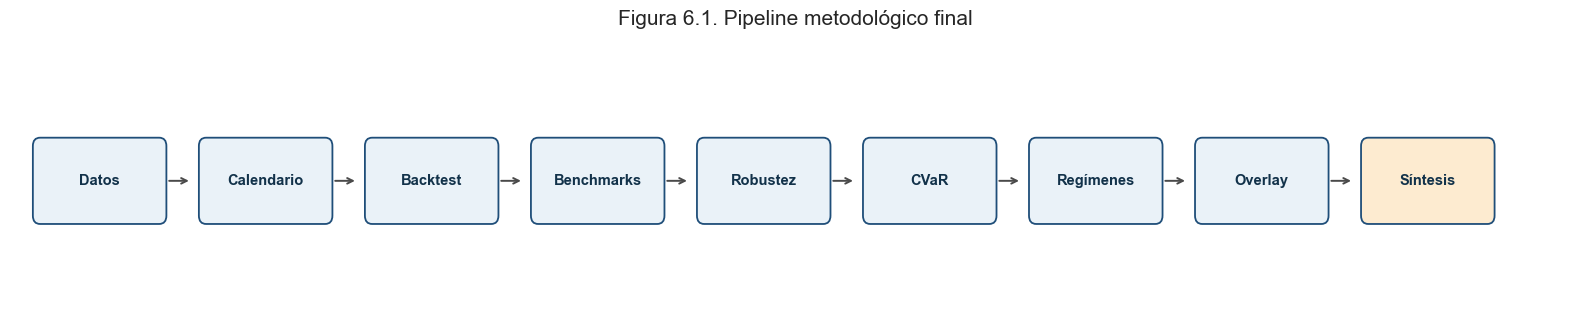

**Qué muestra:** el flujo lógico desde datos y calendario hasta síntesis de evidencia.  
**Qué se observa:** cada bloque responde una pregunta distinta y consume outputs específicos.  
**Qué implica:** la conclusión final debe leerse como acumulación de controles, no como resultado de una sola figura.  
**Punto débil:** el diagrama resume la arquitectura; los supuestos finos quedan documentados en los notebooks de capítulos 1 a 5.

In [418]:
from IPython.display import Markdown, display
from matplotlib.patches import FancyBboxPatch
import matplotlib.pyplot as plt

dataset_meta = CORE_OUTPUTS.get("dataset_metadata") or {}
chapter5_meta = CORE_OUTPUTS.get("chapter5_metadata") or {}

assumption_rows = [
    ["Política de calendario", dataset_meta.get("calendar_policy", "n/d")],
    ["Factor de anualización", dataset_meta.get("annualization_factor", chapter5_meta.get("annualization_factor", "n/d"))],
    ["Método de holding", chapter5_meta.get("holding_return_method", "drifted_buy_and_hold")],
    ["Validación OOS", chapter5_meta.get("validation", {}).get("method", "walk-forward")],
    ["Ventana de entrenamiento", chapter5_meta.get("validation", {}).get("train_window", "n/d")],
    ["Ventana de test", chapter5_meta.get("validation", {}).get("test_window", "n/d")],
    ["Embargo", chapter5_meta.get("validation", {}).get("embargo_days", "n/d")],
    ["Horizonte de datos", f"{dataset_meta.get('start_date', 'n/d')} a {dataset_meta.get('end_date', 'n/d')}"] if dataset_meta else ["Horizonte de datos", "n/d"],
]
assumptions = pd.DataFrame(assumption_rows, columns=["Supuesto", "Valor"])

table_a = pd.DataFrame([
    ["Backtest MinVar", "¿MinVar mejora el perfil retorno-riesgo?", "src/backtest.py; src/optimizer.py; scripts/run_backtest.py", "data/processed/backtest_summary.csv; data/processed/portfolio_returns.csv", "Separar construcción de cartera del benchmark tradicional."],
    ["Benchmarks", "¿El 60/40 es superado en la misma ventana?", "src/benchmarks.py; scripts/run_benchmarks.py", "data/processed/benchmark_summary.csv", "Anclar la comparación frente a una cartera tradicional."],
    ["Control sin crypto", "¿BTC/ETH explican la mejora de MinVar?", "src/robustness.py; scripts/run_robustness.py", "data/processed/robustness/robustness_summary_common_family_net.csv", "Aislar el efecto de permitir crypto frente a la arquitectura MinVar."],
    ["Bootstrap", "¿El delta de Sharpe crypto es robusto?", "src/bootstrap.py; scripts/run_statistical_confidence.py", "data/processed/robustness/confidence_summary.csv", "Distinguir punto estimado favorable de evidencia estadística defendible."],
    ["CVaR y stress", "¿Optimizar cola cambia la tesis?", "src/cvar_optimizer.py; src/stress.py; scripts/run_tail_risk.py", "data/processed/tail_risk/tail_risk_summary_net.csv; data/processed/tail_risk/stress_summary.csv", "Evaluar si el riesgo extremo rescata la asignación crypto."],
    ["Regímenes", "¿El contexto de mercado altera la lectura?", "src/regime_features.py; src/regime_detection.py; src/regime_evaluation.py; scripts/run_regime_analysis.py", "data/processed/regime_analysis/regime_labels.csv; regime_conditional_performance_net.csv; regime_crypto_exposure.csv", "Tratar los estados de mercado como diagnóstico histórico, no como señal live."],
    ["Modelos supervisados", "¿La señal predictiva es útil para riesgo?", "src/supervised_targets.py; src/supervised_features.py; src/supervised_validation.py; src/supervised_models.py; src/model_evaluation.py; scripts/run_chapter5.py", "outputs/chapter5/model_scores.csv; outputs/chapter5/model_selection.csv", "Separar performance predictiva de valor económico."],
    ["Overlay", "¿La capa supervisada mejora la cartera neta?", "src/risk_overlay.py; src/overlay_backtest.py; scripts/run_risk_overlay.py", "outputs/chapter5/overlay_backtest_summary.csv; outputs/chapter5/overlay_decisions.csv", "Medir si las señales cambian pesos y métricas finales."],
], columns=["Bloque", "Pregunta que responde", "Código / script", "Output principal", "Conclusión que permite contrastar"])

display(Markdown("### Supuestos de evaluación"))
display(assumptions.style.hide(axis="index"))
display(Markdown("### Tabla A. Diseño empírico del estudio"))
display(table_a.style.hide(axis="index"))

steps = ["Datos", "Calendario", "Backtest", "Benchmarks", "Robustez", "CVaR", "Regímenes", "Overlay", "Síntesis"]
fig, ax = plt.subplots(figsize=(16, 3.4))
ax.set_xlim(0, len(steps) * 1.45)
ax.set_ylim(0, 2)
ax.axis("off")
for idx, step in enumerate(steps):
    x = 0.22 + idx * 1.38
    box = FancyBboxPatch(
        (x, 0.72), 1.05, 0.56,
        boxstyle="round,pad=0.03,rounding_size=0.06",
        linewidth=1.3,
        edgecolor="#1f4e79",
        facecolor="#eaf2f8" if idx < len(steps) - 1 else "#fdebd0",
    )
    ax.add_patch(box)
    ax.text(x + 0.525, 1.0, step, ha="center", va="center", fontsize=10.5, fontweight="bold", color="#12324a")
    if idx < len(steps) - 1:
        ax.annotate("", xy=(x + 1.29, 1.0), xytext=(x + 1.08, 1.0), arrowprops={"arrowstyle": "->", "lw": 1.4, "color": "#4a4a4a"})
ax.set_title("Figura 6.1. Pipeline metodológico final", fontsize=15, pad=12)
plt.tight_layout()
plt.show()

display(Markdown(
    "**Qué muestra:** el flujo lógico desde datos y calendario hasta síntesis de evidencia.  \n"
    "**Qué se observa:** cada bloque responde una pregunta distinta y consume outputs específicos.  \n"
    "**Qué implica:** la conclusión final debe leerse como acumulación de controles, no como resultado de una sola figura.  \n"
    "**Punto débil:** el diagrama resume la arquitectura; los supuestos finos quedan documentados en los notebooks de capítulos 1 a 5."
))

## 4. Tabla B — Hallazgos por capítulo

La tabla resume qué pregunta responde cada capítulo, qué método usa y qué lectura económica deja para la tesis final. No sustituye las figuras: las prepara.

### Criterio de lectura

Cada fila debe responder una pregunta económica concreta: no basta con reportar una métrica favorable. La lectura se apoya en métricas netas, comparación contra controles y cautela ante diferencias pequeñas.

In [419]:
backtest = CORE_OUTPUTS.get("backtest_summary")
bench = CORE_OUTPUTS.get("benchmark_summary")
conf = CORE_OUTPUTS.get("confidence_summary")
tail = CORE_OUTPUTS.get("tail_risk_summary_net")
regime = CORE_OUTPUTS.get("regime_conditional_perf_net")
model_sel = CORE_OUTPUTS.get("model_selection")
overlay = CORE_OUTPUTS.get("overlay_backtest_summary")

rows = []

mv = pick_row(backtest, "strategy", "min_variance")
sf = pick_row(bench, "benchmark", "sixty_forty")
if not mv.empty and not sf.empty:
    evidence = f"MinVar Sharpe {mv['sharpe']:.2f} vs 60/40 {sf['sharpe']:.2f}; retorno anual {mv['ann_return'] * 100:.1f}% vs {sf['ann_return'] * 100:.1f}%."
else:
    evidence = "Filas MinVar/60-40 no disponibles en los resúmenes cargados."
rows.append(["Capítulo 1", "¿La construcción MinVar mejora al 60/40?", "Backtest OOS con costes y drifted buy-and-hold", evidence, "El beneficio principal procede de la construcción risk-based.", "Dependencia del periodo y del universo de activos."])

c1 = pd.DataFrame()
if conf is not None and not conf.empty and "comparison_id" in conf.columns:
    c1 = conf.loc[conf["comparison_id"] == "C1_anchor_pair"]
if not c1.empty:
    r = c1.iloc[0]
    evidence = f"Δ Sharpe crypto {r['point_estimate_difference']:+.3f}; IC [{r['ci_lower']:+.3f}, {r['ci_upper']:+.3f}]."
else:
    evidence = "Comparación bootstrap C1 no disponible."
rows.append(["Capítulo 2", "¿El permiso a crypto es robusto?", "Control sin crypto y bootstrap por bloques", evidence, "Un punto estimado positivo no basta si el intervalo cruza cero.", "El bootstrap no elimina riesgo de especificación ni múltiples comparaciones."])

cvar = pick_row(tail, "strategy", "cvar_baseline")
minvar_tail = pick_row(tail, "strategy", "minvar_baseline_ch1")
if not cvar.empty and not minvar_tail.empty:
    evidence = f"CVaR Sharpe {cvar['sharpe_net']:.3f} vs MinVar {minvar_tail['sharpe_net']:.3f}; ES95 {cvar['expected_shortfall_net'] * 100:.2f}% vs {minvar_tail['expected_shortfall_net'] * 100:.2f}%."
else:
    evidence = "Filas CVaR/MinVar no disponibles."
rows.append(["Capítulo 3", "¿Optimizar cola cambia la conclusión?", "Minimización CVaR histórica y ventanas de stress", evidence, "CVaR sirve como prueba de cola, pero no domina de forma económica clara.", "ES95 y MaxDD requieren leer dirección de mejora con cuidado."])

mv_reg = regime.loc[regime["strategy"] == "minvar_baseline_ch1"] if regime is not None and not regime.empty else pd.DataFrame()
if not mv_reg.empty:
    low = mv_reg.loc[mv_reg["regime_name"] == "Low-stress / Risk-on", "sharpe"]
    high = mv_reg.loc[mv_reg["regime_name"] == "High-stress / Risk-off", "sharpe"]
    evidence = f"Sharpe MinVar {float(low.iloc[0]):.2f} en riesgo contenido vs {float(high.iloc[0]):.2f} en estrés alto." if not low.empty and not high.empty else "Performance condicional incompleta."
else:
    evidence = "Tabla de performance por régimen no disponible."
rows.append(["Capítulo 4", "¿El contexto de mercado cambia la lectura?", "Features de régimen, clustering/estado y evaluación condicional", evidence, "Los regímenes son diagnóstico histórico; no validan una regla predictiva live.", "Resultados sensibles a definición de estados y muestra."])

if model_sel is not None and not model_sel.empty:
    improved = int(model_sel["improved_vs_naive"].fillna(False).sum())
    total = len(model_sel)
    evidence = f"{improved}/{total} targets seleccionan un modelo que mejora al naive."
else:
    evidence = "Selección de modelos no disponible."
rows.append(["Capítulo 5", "¿La señal supervisada mejora la cartera?", "Validación OOS de targets de riesgo y backtest de overlay", evidence, "Señal predictiva y valor económico son cosas distintas; el overlay debe juzgarse por métricas netas.", "Riesgo de selección de targets, calibración y transferencia temporal."])

findings_df = pd.DataFrame(rows, columns=["Capítulo", "Pregunta", "Método", "Evidencia clave", "Lectura económica", "Limitación"])
display(findings_df.style.hide(axis="index"))

Capítulo,Pregunta,Método,Evidencia clave,Lectura económica,Limitación
Capítulo 1,¿La construcción MinVar mejora al 60/40?,Backtest OOS con costes y drifted buy-and-hold,MinVar Sharpe 1.10 vs 60/40 0.76; retorno anual 11.8% vs 9.4%.,El beneficio principal procede de la construcción risk-based.,Dependencia del periodo y del universo de activos.
Capítulo 2,¿El permiso a crypto es robusto?,Control sin crypto y bootstrap por bloques,"Δ Sharpe crypto +0.007; IC [-0.024, +0.042].",Un punto estimado positivo no basta si el intervalo cruza cero.,El bootstrap no elimina riesgo de especificación ni múltiples comparaciones.
Capítulo 3,¿Optimizar cola cambia la conclusión?,Minimización CVaR histórica y ventanas de stress,CVaR Sharpe 1.095 vs MinVar 1.093; ES95 1.59% vs 1.55%.,"CVaR sirve como prueba de cola, pero no domina de forma económica clara.",ES95 y MaxDD requieren leer dirección de mejora con cuidado.
Capítulo 4,¿El contexto de mercado cambia la lectura?,"Features de régimen, clustering/estado y evaluación condicional",Sharpe MinVar 1.63 en riesgo contenido vs 0.15 en estrés alto.,Los regímenes son diagnóstico histórico; no validan una regla predictiva live.,Resultados sensibles a definición de estados y muestra.
Capítulo 5,¿La señal supervisada mejora la cartera?,Validación OOS de targets de riesgo y backtest de overlay,10/12 targets seleccionan un modelo que mejora al naive.,Señal predictiva y valor económico son cosas distintas; el overlay debe juzgarse por métricas netas.,"Riesgo de selección de targets, calibración y transferencia temporal."


**Lectura analítica.** La tabla muestra una estructura de falsación progresiva. Primero se valida si MinVar mejora al 60/40; después se pregunta si crypto explica esa mejora; finalmente se tensiona la conclusión con cola, regímenes y overlay supervisado. La evidencia se debilita justo donde el claim crypto tendría que fortalecerse.

## 5. Tabla E — Evidencia frente a hipótesis

Esta tabla funciona como control de overclaiming. Cada afirmación se juzga contra evidencia concreta, confianza y punto débil. El objetivo no es cerrar una verdad universal, sino identificar qué queda defendible con los outputs disponibles.

### Criterio de veredicto

Los veredictos distinguen entre evidencia favorable, evidencia insuficiente y evidencia contraria. Las diferencias pequeñas, los intervalos que cruzan cero y las exposiciones medias muy bajas reducen la fuerza del claim aunque el punto estimado tenga el signo esperado.

In [420]:
backtest = CORE_OUTPUTS.get("backtest_summary")
bench = CORE_OUTPUTS.get("benchmark_summary")
conf = CORE_OUTPUTS.get("confidence_summary")
tail = CORE_OUTPUTS.get("tail_risk_summary_net")
regime_perf = CORE_OUTPUTS.get("regime_conditional_perf_net")
overlay_summary = CORE_OUTPUTS.get("overlay_backtest_summary")
weights_history = CORE_OUTPUTS.get("weights_history")

baseline_row = pick_row(overlay_summary, "strategy", "minvar_baseline_corrected")
no_crypto_row = pick_row(overlay_summary, "strategy", "minvar_no_crypto_control")
overlay_row = pick_row(overlay_summary, "strategy", "minvar_combined_overlay")
bench_6040 = pick_row(bench, "benchmark", "sixty_forty")
backtest_minvar = pick_row(backtest, "strategy", "min_variance")

rows = []
if not bench_6040.empty and not backtest_minvar.empty:
    evidence = f"Sharpe {backtest_minvar['sharpe']:.2f} vs {bench_6040['sharpe']:.2f}; retorno anual {backtest_minvar['ann_return'] * 100:.1f}% vs {bench_6040['ann_return'] * 100:.1f}%."
else:
    evidence = "Comparación MinVar/60-40 no disponible."
rows.append(["MinVar mejora frente al 60/40.", evidence, "Sí, en esta muestra", "Alta", "No implica superioridad universal fuera del periodo evaluado."])

crypto_evidence = "Control sin crypto o bootstrap no disponible."
crypto_confidence = "Media"
if not baseline_row.empty and not no_crypto_row.empty:
    delta_sharpe = metric_value(baseline_row, "sharpe") - metric_value(no_crypto_row, "sharpe")
    crypto_evidence = f"Δ Sharpe {delta_sharpe:+.3f}."
    if conf is not None and not conf.empty:
        c1 = conf.loc[conf["comparison_id"] == "C1_anchor_pair"]
        if not c1.empty:
            r = c1.iloc[0]
            crypto_evidence = f"Δ Sharpe {delta_sharpe:+.3f}; IC [{r['ci_lower']:+.3f}, {r['ci_upper']:+.3f}]."
            crypto_confidence = "Alta" if bool(r["ci_includes_zero"]) else "Media"
rows.append(["Crypto explica la mejora.", crypto_evidence, "No defendible", crypto_confidence, "El efecto incremental es pequeño y el IC cruza cero."])

crypto_weight_evidence = "Panel de pesos no disponible."
if weights_history is not None and not weights_history.empty:
    crypto_cols = [col for col in ["BTC-USD", "ETH-USD"] if col in weights_history.columns]
    if crypto_cols:
        focus = weights_history[crypto_cols].sum(axis=1)
        crypto_weight_evidence = f"Peso medio {focus.mean() * 100:.2f}%; mediana {focus.median() * 100:.2f}%; >2% en {(focus > 0.02).mean() * 100:.1f}% de rebalanceos."
rows.append(["Crypto es asignación estructural.", crypto_weight_evidence, "No", "Alta", "Una asignación estructural debería ser frecuente y material."])
rows.append(["Crypto es exposición táctica.", crypto_weight_evidence, "Compatible", "Alta", "Táctica no significa necesariamente rentable o escalable."])

cvar_evidence = "Comparación CVaR-MinVar no disponible."
if tail is not None and not tail.empty:
    cvar_row = pick_row(tail, "strategy", "cvar_baseline")
    minvar_row = pick_row(tail, "strategy", "minvar_baseline_ch1")
    if not cvar_row.empty and not minvar_row.empty:
        cvar_evidence = f"Sharpe {metric_value(cvar_row, 'sharpe_net'):.3f} vs {metric_value(minvar_row, 'sharpe_net'):.3f}; ES95 {metric_value(cvar_row, 'expected_shortfall_net') * 100:.2f}% vs {metric_value(minvar_row, 'expected_shortfall_net') * 100:.2f}%."
rows.append(["CVaR domina.", cvar_evidence, "No claro", "Media", "Las diferencias de cola y retorno son pequeñas."])

regime_evidence = "Performance por régimen no disponible."
if regime_perf is not None and not regime_perf.empty:
    mv_reg = regime_perf.loc[regime_perf["strategy"] == "minvar_baseline_ch1"]
    low = mv_reg.loc[mv_reg["regime_name"] == "Low-stress / Risk-on", "sharpe"]
    high = mv_reg.loc[mv_reg["regime_name"] == "High-stress / Risk-off", "sharpe"]
    if not low.empty and not high.empty:
        regime_evidence = f"Sharpe MinVar {float(low.iloc[0]):.2f} en riesgo contenido vs {float(high.iloc[0]):.2f} en estrés alto."
rows.append(["Regímenes cambian la interpretación.", regime_evidence, "Sí, como diagnóstico", "Media", "No son una señal predictiva live validada."])

overlay_evidence = "Comparación overlay-MinVar no disponible."
if not baseline_row.empty and not overlay_row.empty:
    overlay_evidence = f"Δ Sharpe {metric_value(overlay_row, 'sharpe') - metric_value(baseline_row, 'sharpe'):+.3f}; Δ ES95 {(metric_value(overlay_row, 'es95') - metric_value(baseline_row, 'es95')) * 100:+.2f} p.p."
rows.append(["ML/overlay aporta valor económico.", overlay_evidence, "No robusto", "Media", "La señal predictiva no se traduce claramente en mejora neta de cartera."])

rows.append(["El framework incorpora controles robustos.", "Control sin crypto, costes, bootstrap, CVaR, regímenes y overlay disponibles.", "Sí, con cautela", "Alta", "Metodológicamente defendible no significa universal ni libre de riesgo de especificación."])

claim_df = pd.DataFrame(rows, columns=["Hipótesis / afirmación", "Evidencia", "Veredicto", "Confianza", "Punto débil"])
display(claim_df.style.hide(axis="index"))

Hipótesis / afirmación,Evidencia,Veredicto,Confianza,Punto débil
MinVar mejora frente al 60/40.,Sharpe 1.10 vs 0.76; retorno anual 11.8% vs 9.4%.,"Sí, en esta muestra",Alta,No implica superioridad universal fuera del periodo evaluado.
Crypto explica la mejora.,"Δ Sharpe +0.011; IC [-0.024, +0.042].",No defendible,Alta,El efecto incremental es pequeño y el IC cruza cero.
Crypto es asignación estructural.,Peso medio 0.53%; mediana 0.00%; >2% en 6.7% de rebalanceos.,No,Alta,Una asignación estructural debería ser frecuente y material.
Crypto es exposición táctica.,Peso medio 0.53%; mediana 0.00%; >2% en 6.7% de rebalanceos.,Compatible,Alta,Táctica no significa necesariamente rentable o escalable.
CVaR domina.,Sharpe 1.095 vs 1.093; ES95 1.59% vs 1.55%.,No claro,Media,Las diferencias de cola y retorno son pequeñas.
Regímenes cambian la interpretación.,Sharpe MinVar 1.63 en riesgo contenido vs 0.15 en estrés alto.,"Sí, como diagnóstico",Media,No son una señal predictiva live validada.
ML/overlay aporta valor económico.,Δ Sharpe -0.038; Δ ES95 -0.00 p.p.,No robusto,Media,La señal predictiva no se traduce claramente en mejora neta de cartera.
El framework incorpora controles robustos.,"Control sin crypto, costes, bootstrap, CVaR, regímenes y overlay disponibles.","Sí, con cautela",Alta,Metodológicamente defendible no significa universal ni libre de riesgo de especificación.


**Lectura analítica.** La tabla separa evidencia favorable de atribución causal. MinVar puede mejorar al 60/40 sin que BTC/ETH expliquen esa mejora. La conclusión central queda condicionada por materialidad, robustez estadística y exposición efectiva.

## 5.1. Tablas C y D — Estrategias finales y atribución económica

Antes del bloque visual, estas tablas separan dos niveles de lectura: desempeño/riesgo de cada estrategia e impacto incremental de cada capa metodológica. Esta separación evita atribuir a crypto lo que puede venir de la construcción MinVar.

In [421]:
def _fmt_pct_value(value: float, decimals: int = 1) -> str:
    if value is None or pd.isna(value):
        return "n/d"
    return f"{float(value) * 100:.{decimals}f}%"

bench = CORE_OUTPUTS.get("benchmark_summary")
overlay_summary = CORE_OUTPUTS.get("overlay_backtest_summary")
tail_net = CORE_OUTPUTS.get("tail_risk_summary_net")

bench_6040 = pick_row(bench, "benchmark", "sixty_forty")
baseline_row = pick_row(overlay_summary, "strategy", "minvar_baseline_corrected")
no_crypto_row = pick_row(overlay_summary, "strategy", "minvar_no_crypto_control")
overlay_combined_row = pick_row(overlay_summary, "strategy", "minvar_combined_overlay")

strategy_rows = []

def _append_strategy(label: str, row: pd.Series, source: str) -> None:
    if row is None or row.empty:
        return
    crypto_rebalances = metric_value(row, "n_rebalances_crypto_gt_2pct", "n_crypto_rebalances_gt_2pct")
    strategy_rows.append({
        "Estrategia": label,
        "Retorno anual": _fmt_pct_value(metric_value(row, "ann_return", "annualized_return", "ann_return_net")),
        "Volatilidad anual": _fmt_pct_value(metric_value(row, "ann_volatility", "annualized_volatility", "ann_volatility_net")),
        "Sharpe": f"{metric_value(row, 'sharpe', 'sharpe_net'):.3f}",
        "Max drawdown": _fmt_pct_value(metric_value(row, "max_drawdown", "max_drawdown_net")),
        "ES95": _fmt_pct_value(metric_value(row, "es95", "expected_shortfall_net")),
        "Turnover": _fmt_pct_value(metric_value(row, "avg_turnover", "turnover", "turnover_one_way")),
        "Costes": _fmt_pct_value(metric_value(row, "total_costs", "cumulative_cost"), decimals=2),
        "Peso crypto medio": _fmt_pct_value(metric_value(row, "avg_crypto_weight", "crypto_avg_weight"), decimals=2),
        "Peso crypto máximo": _fmt_pct_value(metric_value(row, "max_crypto_weight", "crypto_max_weight"), decimals=2),
        "Rebalances crypto >2%": int(crypto_rebalances) if pd.notna(crypto_rebalances) else "n/d",
        "Fuente": source,
    })

_append_strategy("60/40 tradicional", bench_6040, "benchmark_summary.csv")
_append_strategy("MinVar", baseline_row, "overlay_backtest_summary.csv")
_append_strategy("MinVar sin crypto", no_crypto_row, "overlay_backtest_summary.csv")
if tail_net is not None and not tail_net.empty:
    _append_strategy("CVaR", pick_row(tail_net, "strategy", "cvar_baseline"), "tail_risk_summary_net.csv")
    _append_strategy("CVaR sin crypto", pick_row(tail_net, "strategy", "cvar_no_crypto_control"), "tail_risk_summary_net.csv")
if overlay_summary is not None and not overlay_summary.empty:
    _append_strategy("Overlay riesgo simple", pick_row(overlay_summary, "strategy", "minvar_dynamic_crypto_cap_naive_vol"), "overlay_backtest_summary.csv")
    _append_strategy("Overlay riesgo ML", pick_row(overlay_summary, "strategy", "minvar_dynamic_crypto_cap_ml_vol"), "overlay_backtest_summary.csv")
    _append_strategy("Overlay combinado", overlay_combined_row, "overlay_backtest_summary.csv")

strategy_table = pd.DataFrame(strategy_rows)
perf_cols = ["Estrategia", "Retorno anual", "Volatilidad anual", "Sharpe", "Max drawdown", "ES95"]
impl_cols = ["Estrategia", "Turnover", "Costes", "Peso crypto medio", "Peso crypto máximo", "Rebalances crypto >2%", "Fuente"]

display(Markdown("### Tabla C1. Performance y riesgo"))
display(strategy_table[perf_cols].style.hide(axis="index"))
display(Markdown("### Tabla C2. Implementabilidad y exposición"))
display(strategy_table[impl_cols].style.hide(axis="index"))

def _delta_row(effect: str, comparison: str, left: pd.Series, right: pd.Series, interpretation: str) -> dict:
    return {
        "Efecto": effect,
        "Comparación": comparison,
        "Δ Retorno": f"{(metric_value(left, 'ann_return', 'annualized_return', 'ann_return_net') - metric_value(right, 'ann_return', 'annualized_return', 'ann_return_net')) * 100:+.2f} p.p.",
        "Δ Sharpe": f"{metric_value(left, 'sharpe', 'sharpe_net') - metric_value(right, 'sharpe', 'sharpe_net'):+.3f}",
        "Δ MaxDD": f"{(metric_value(left, 'max_drawdown', 'max_drawdown_net') - metric_value(right, 'max_drawdown', 'max_drawdown_net')) * 100:+.2f} p.p.",
        "Δ ES95": f"{(metric_value(left, 'es95', 'expected_shortfall_net') - metric_value(right, 'es95', 'expected_shortfall_net')) * 100:+.2f} p.p.",
        "Interpretación": interpretation,
    }

attrib_rows = []
if not baseline_row.empty and not bench_6040.empty:
    attrib_rows.append(_delta_row("Construcción MinVar", "MinVar vs 60/40", baseline_row, bench_6040, "Mejora asociada al framework de construcción de cartera."))
if not baseline_row.empty and not no_crypto_row.empty:
    attrib_rows.append(_delta_row("Permitir crypto", "MinVar vs MinVar sin crypto", baseline_row, no_crypto_row, "Diferencia pequeña; no basta para atribución estructural a BTC/ETH."))
if tail_net is not None and not tail_net.empty:
    cvar_row = pick_row(tail_net, "strategy", "cvar_baseline")
    minvar_tail = pick_row(tail_net, "strategy", "minvar_baseline_ch1")
    if not cvar_row.empty and not minvar_tail.empty:
        attrib_rows.append(_delta_row("Objetivo de cola", "CVaR vs MinVar", cvar_row, minvar_tail, "Prueba de cola; mejora solo si reduce pérdidas sin sacrificar perfil neto."))
if not overlay_combined_row.empty and not baseline_row.empty:
    attrib_rows.append(_delta_row("Overlay", "Overlay combinado vs MinVar", overlay_combined_row, baseline_row, "Control supervisado trazable, pero valor económico limitado si no mejora métricas netas."))
if overlay_summary is not None and not overlay_summary.empty:
    simple_row = pick_row(overlay_summary, "strategy", "minvar_dynamic_crypto_cap_naive_vol")
    ml_row = pick_row(overlay_summary, "strategy", "minvar_dynamic_crypto_cap_ml_vol")
    if not simple_row.empty and not ml_row.empty:
        attrib_rows.append(_delta_row("ML incremental", "Overlay ML vs overlay simple", ml_row, simple_row, "Aísla si ML añade algo frente a una regla simple de riesgo."))

attrib_table = pd.DataFrame(attrib_rows)
display(Markdown("### Tabla D. Atribución económica"))
display(attrib_table.style.hide(axis="index"))

### Tabla C1. Performance y riesgo

Estrategia,Retorno anual,Volatilidad anual,Sharpe,Max drawdown,ES95
60/40 tradicional,9.4%,12.2%,0.764,-27.7%,n/d
MinVar,11.8%,10.8%,1.093,-23.4%,1.6%
MinVar sin crypto,11.6%,10.7%,1.082,-23.4%,1.5%
CVaR,12.0%,11.0%,1.095,-23.3%,1.6%
CVaR sin crypto,11.7%,10.9%,1.071,-23.2%,1.6%
Overlay riesgo simple,11.8%,10.8%,1.093,-23.4%,1.6%
Overlay riesgo ML,11.8%,10.8%,1.093,-23.4%,1.6%
Overlay combinado,11.4%,10.8%,1.055,-24.6%,1.6%


### Tabla C2. Implementabilidad y exposición

Estrategia,Turnover,Costes,Peso crypto medio,Peso crypto máximo,Rebalances crypto >2%,Fuente
60/40 tradicional,n/d,n/d,n/d,n/d,n/d,benchmark_summary.csv
MinVar,2.7%,0.24%,0.53%,3.23%,6,overlay_backtest_summary.csv
MinVar sin crypto,2.6%,0.22%,0.00%,0.00%,0,overlay_backtest_summary.csv
CVaR,n/d,n/d,n/d,n/d,n/d,tail_risk_summary_net.csv
CVaR sin crypto,n/d,n/d,n/d,n/d,n/d,tail_risk_summary_net.csv
Overlay riesgo simple,2.7%,0.24%,0.53%,3.23%,6,overlay_backtest_summary.csv
Overlay riesgo ML,2.7%,0.24%,0.53%,3.23%,6,overlay_backtest_summary.csv
Overlay combinado,4.0%,0.35%,0.53%,3.23%,6,overlay_backtest_summary.csv


### Tabla D. Atribución económica

Efecto,Comparación,Δ Retorno,Δ Sharpe,Δ MaxDD,Δ ES95,Interpretación
Construcción MinVar,MinVar vs 60/40,+2.41 p.p.,+0.329,+4.23 p.p.,+nan p.p.,Mejora asociada al framework de construcción de cartera.
Permitir crypto,MinVar vs MinVar sin crypto,+0.17 p.p.,+0.011,-0.00 p.p.,+0.01 p.p.,Diferencia pequeña; no basta para atribución estructural a BTC/ETH.
Objetivo de cola,CVaR vs MinVar,+0.24 p.p.,+0.002,+0.17 p.p.,+0.03 p.p.,Prueba de cola; mejora solo si reduce pérdidas sin sacrificar perfil neto.
Overlay,Overlay combinado vs MinVar,-0.40 p.p.,-0.038,-1.19 p.p.,-0.00 p.p.,"Control supervisado trazable, pero valor económico limitado si no mejora métricas netas."
ML incremental,Overlay ML vs overlay simple,+0.00 p.p.,+0.000,+0.00 p.p.,+0.00 p.p.,Aísla si ML añade algo frente a una regla simple de riesgo.


## 6. Bloque visual de síntesis

Este tramo rehace la narrativa gráfica final del proyecto para que la conclusión pueda entenderse mirando primero las figuras y después el texto.

### Figura 6.1 — Mapa del pipeline metodológico

Resumen visual del flujo completo: desde los datos auditados hasta la síntesis final, sin entrenar modelos ni ejecutar pipelines pesados dentro de este notebook.

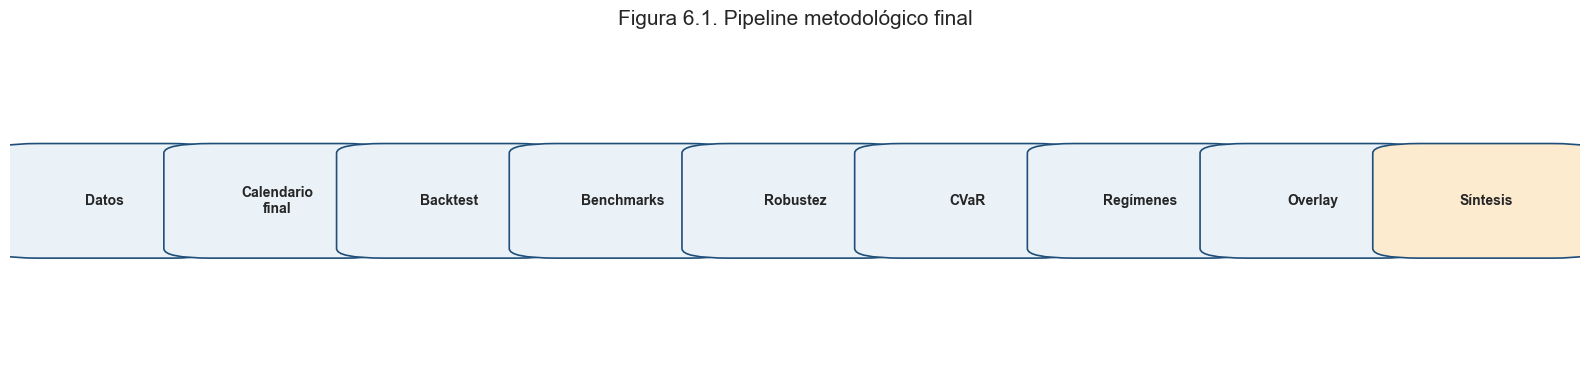

**Qué muestra:** El flujo del estudio desde los datos hasta la síntesis final, usando solo la metodología final del proyecto.  \n**Qué se observa:** La historia visual combina construcción de cartera, benchmark tradicional, robustez, cola, regímenes y overlay en una única secuencia de validación.  \n**Qué implica:** La conclusión económica no descansa en un único experimento, sino en la consistencia del pipeline completo bajo la metodología final.  \n**Limitación:** Es un mapa conceptual: resume el proceso, pero no sustituye el detalle técnico de los notebooks de capítulos 1 a 5.

In [422]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#fbfbf8",
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

VIS_STRATEGY_NAMES = {
    "sixty_forty": "60/40 tradicional",
    "min_variance": "MinVar",
    "minvar_baseline_ch1": "MinVar",
    "minvar_baseline_corrected": "MinVar",
    "minvar_no_crypto_control": "MinVar sin crypto",
    "cvar_baseline": "CVaR",
    "cvar_no_crypto_control": "CVaR sin crypto",
    "minvar_dynamic_crypto_cap_naive_vol": "Overlay riesgo simple",
    "minvar_dynamic_crypto_cap_ml_vol": "Overlay riesgo ML",
    "minvar_dynamic_crypto_cap_stress_probability": "Overlay estrés",
    "minvar_combined_overlay": "Overlay combinado",
}

VIS_COLORS = {
    "60/40 tradicional": "#5b8e7d",
    "MinVar": "#1f4e79",
    "MinVar sin crypto": "#b36a2e",
    "CVaR": "#8f3b76",
    "CVaR sin crypto": "#c77dbb",
    "Overlay riesgo simple": "#4c78a8",
    "Overlay riesgo ML": "#f58518",
    "Overlay estrés": "#e45756",
    "Overlay combinado": "#c84c09",
}

VIS_REGIME_NAMES = {
    "Low-stress / Risk-on": "Riesgo contenido",
    "High-stress / Risk-off": "Estrés alto",
}

VIS_REGIME_COLORS = {
    "Riesgo contenido": "#72b7b2",
    "Estrés alto": "#e45756",
}

def vis_h_strategy(name: str) -> str:
    return VIS_STRATEGY_NAMES.get(name, humanize_strategy(name).replace("without crypto", "sin crypto"))


def vis_h_regime(name: str) -> str:
    return VIS_REGIME_NAMES.get(name, name)


def vis_pct_axis(ax, axis: str = "y", decimals: int = 0) -> None:
    formatter = mtick.PercentFormatter(xmax=1.0, decimals=decimals)
    if axis == "x":
        ax.xaxis.set_major_formatter(formatter)
    else:
        ax.yaxis.set_major_formatter(formatter)


def vis_note(message: str) -> None:
    display(Markdown(f"> **Nota:** {message}"))


def vis_show_reading(que: str, obs: str, imp: str, lim: str) -> None:
    display(Markdown(
        f"**Qué muestra:** {que}  \\n"
        f"**Qué se observa:** {obs}  \\n"
        f"**Qué implica:** {imp}  \\n"
        f"**Limitación:** {lim}"
    ))


def vis_metric(row: pd.Series, *candidates: str) -> float:
    for candidate in candidates:
        if candidate in row.index and pd.notna(row[candidate]):
            return float(row[candidate])
    return float("nan")


def vis_pick_row(df: pd.DataFrame | None, column: str, value: str) -> pd.Series:
    if df is None or df.empty or column not in df.columns:
        return pd.Series(dtype=float)
    match = df.loc[df[column] == value]
    return match.iloc[0] if not match.empty else pd.Series(dtype=float)


def vis_load_output(key: str, fallback_path: Path, **kwargs) -> pd.DataFrame | None:
    value = CORE_OUTPUTS.get(key)
    if value is not None:
        return value
    return safe_read_csv(fallback_path, **kwargs)


def vis_build_series_map() -> dict[str, pd.Series]:
    series_map: dict[str, pd.Series] = {}

    portfolio_returns = CORE_OUTPUTS.get("portfolio_returns")
    if portfolio_returns is not None and {"Date", "sixty_forty", "min_variance"}.issubset(portfolio_returns.columns):
        tmp = portfolio_returns.copy()
        tmp["Date"] = pd.to_datetime(tmp["Date"])
        tmp = tmp.set_index("Date").sort_index()
        series_map["60/40 tradicional"] = tmp["sixty_forty"].astype(float)
        series_map["MinVar"] = tmp["min_variance"].astype(float)

    overlay_daily_returns = vis_load_output(
        "overlay_daily_returns",
        CHAPTER5_DIR / "overlay_daily_returns.csv",
        parse_dates=["date"],
    )
    if overlay_daily_returns is not None and {"date", "daily_return", "strategy"}.issubset(overlay_daily_returns.columns):
        tmp = overlay_daily_returns.copy()
        tmp["date"] = pd.to_datetime(tmp["date"])
        for strategy in ["minvar_baseline_corrected", "minvar_no_crypto_control", "minvar_combined_overlay"]:
            subset = tmp.loc[tmp["strategy"] == strategy, ["date", "daily_return"]]
            if not subset.empty:
                series_map[vis_h_strategy(strategy)] = subset.set_index("date")["daily_return"].astype(float).sort_index()

    tail_risk_returns = vis_load_output(
        "tail_risk_returns",
        TAIL_RISK_DIR / "tail_risk_returns.csv",
        parse_dates=["date"],
    )
    if tail_risk_returns is not None and {"date", "portfolio_return", "strategy"}.issubset(tail_risk_returns.columns):
        tmp = tail_risk_returns.copy()
        tmp["date"] = pd.to_datetime(tmp["date"])
        for strategy in ["cvar_baseline", "cvar_no_crypto_control"]:
            subset = tmp.loc[tmp["strategy"] == strategy, ["date", "portfolio_return"]]
            if not subset.empty:
                series_map[vis_h_strategy(strategy)] = subset.set_index("date")["portfolio_return"].astype(float).sort_index()

    return series_map


VIS_SERIES_MAP = vis_build_series_map()
VIS_COMMON_NAMES = ["60/40 tradicional", "MinVar", "MinVar sin crypto"]
VIS_COMMON_RETURNS = pd.concat(
    [VIS_SERIES_MAP[name].rename(name) for name in VIS_COMMON_NAMES if name in VIS_SERIES_MAP],
    axis=1,
    join="inner",
).dropna(how="any") if all(name in VIS_SERIES_MAP for name in VIS_COMMON_NAMES) else pd.DataFrame()
VIS_COMMON_WEALTH = VIS_COMMON_RETURNS.apply(compute_wealth) if not VIS_COMMON_RETURNS.empty else pd.DataFrame()
VIS_COMMON_DRAWDOWN = VIS_COMMON_RETURNS.apply(compute_drawdown) if not VIS_COMMON_RETURNS.empty else pd.DataFrame()

VIS_BACKTEST = CORE_OUTPUTS.get("backtest_summary")
VIS_BENCH = CORE_OUTPUTS.get("benchmark_summary")
VIS_OVERLAY_SUMMARY = vis_load_output("overlay_backtest_summary", CHAPTER5_DIR / "overlay_backtest_summary.csv")
VIS_OVERLAY_WEIGHTS = vis_load_output(
    "overlay_weights",
    CHAPTER5_DIR / "overlay_weights.csv",
    parse_dates=["rebalance_date"],
 )
VIS_OVERLAY_DECISIONS = vis_load_output(
    "overlay_decisions",
    CHAPTER5_DIR / "overlay_decisions.csv",
    parse_dates=["date"],
 )
VIS_WEIGHTS_HISTORY = CORE_OUTPUTS.get("weights_history")
VIS_TAIL_NET = vis_load_output("tail_risk_summary_net", TAIL_RISK_DIR / "tail_risk_summary_net.csv")
VIS_TAIL_WEIGHTS = vis_load_output(
    "tail_risk_weights_panel",
    TAIL_RISK_DIR / "tail_risk_weights_panel.csv",
    parse_dates=["rebalance_date"],
 )
VIS_STRESS = vis_load_output("stress_summary", TAIL_RISK_DIR / "stress_summary.csv")
VIS_CONFIDENCE = vis_load_output("confidence_summary", ROBUSTNESS_DIR / "confidence_summary.csv")
VIS_ROBUSTNESS = vis_load_output("robustness_common_family_net", ROBUSTNESS_DIR / "robustness_summary_common_family_net.csv")
VIS_REGIME_PERF = safe_read_csv(REGIME_DIR / "regime_conditional_performance_net.csv")
VIS_REGIME_CRYPTO = vis_load_output("regime_crypto_exposure", REGIME_DIR / "regime_crypto_exposure.csv")
VIS_REGIME_LABELS = safe_read_csv(REGIME_DIR / "regime_labels.csv", parse_dates=["date"])
VIS_MODEL_SCORES = vis_load_output("model_scores", CHAPTER5_DIR / "model_scores.csv")
VIS_MODEL_SELECTION = vis_load_output("model_selection", CHAPTER5_DIR / "model_selection.csv")
VIS_FORECAST_BUCKETS = vis_load_output("forecast_bucket_analysis", CHAPTER5_DIR / "forecast_bucket_analysis.csv")
VIS_CALIBRATION = vis_load_output("calibration_tables", CHAPTER5_DIR / "calibration_tables.csv")
VIS_AUDIT = vis_load_output("audit_fix_comparison", OUTPUTS_DIR / "audit_fix_comparison.csv")

VIS_BASELINE_ROW = vis_pick_row(VIS_OVERLAY_SUMMARY, "strategy", "minvar_baseline_corrected")
VIS_NO_CRYPTO_ROW = vis_pick_row(VIS_OVERLAY_SUMMARY, "strategy", "minvar_no_crypto_control")
VIS_OVERLAY_ROW = vis_pick_row(VIS_OVERLAY_SUMMARY, "strategy", "minvar_combined_overlay")

def vis_prepare_crypto_panel() -> pd.DataFrame:
    frames: list[pd.DataFrame] = []
    crypto_cols = ["BTC-USD", "ETH-USD"]

    if VIS_WEIGHTS_HISTORY is not None and not VIS_WEIGHTS_HISTORY.empty:
        tmp = VIS_WEIGHTS_HISTORY.copy()
        tmp["rebalance_date"] = pd.to_datetime(tmp["rebalance_date"])
        tmp["strategy"] = "minvar_baseline_corrected"
        tmp["crypto_total"] = tmp[[col for col in crypto_cols if col in tmp.columns]].sum(axis=1)
        frames.append(tmp[["rebalance_date", "strategy", "crypto_total"]])

    if VIS_OVERLAY_WEIGHTS is not None and not VIS_OVERLAY_WEIGHTS.empty:
        tmp = VIS_OVERLAY_WEIGHTS.copy()
        tmp["rebalance_date"] = pd.to_datetime(tmp["rebalance_date"])
        tmp["crypto_total"] = tmp[[col for col in crypto_cols if col in tmp.columns]].sum(axis=1)
        frames.append(tmp[["rebalance_date", "strategy", "crypto_total"]])

    if VIS_TAIL_WEIGHTS is not None and not VIS_TAIL_WEIGHTS.empty:
        tmp = VIS_TAIL_WEIGHTS.copy()
        tmp["rebalance_date"] = pd.to_datetime(tmp["rebalance_date"])
        tmp["crypto_total"] = tmp[[col for col in crypto_cols if col in tmp.columns]].sum(axis=1)
        frames.append(tmp[["rebalance_date", "strategy", "crypto_total"]])

    if not frames:
        return pd.DataFrame(columns=["rebalance_date", "strategy", "crypto_total", "Estrategia"])

    panel = pd.concat(frames, ignore_index=True)
    panel = panel.dropna(subset=["crypto_total"]).drop_duplicates(subset=["rebalance_date", "strategy"])
    panel["Estrategia"] = panel["strategy"].map(vis_h_strategy)
    return panel.sort_values(["Estrategia", "rebalance_date"])


VIS_CRYPTO_PANEL = vis_prepare_crypto_panel()

fig, ax = plt.subplots(figsize=(16, 3.8))
ax.axis("off")
steps = [
    ("Datos", 0.06),
    ("Calendario\nfinal", 0.17),
    ("Backtest", 0.28),
    ("Benchmarks", 0.39),
    ("Robustez", 0.50),
    ("CVaR", 0.61),
    ("Regímenes", 0.72),
    ("Overlay", 0.83),
    ("Síntesis", 0.94),
]

for idx, (label, xpos) in enumerate(steps):
    box = FancyBboxPatch(
        (xpos - 0.052, 0.34),
        0.104,
        0.32,
        boxstyle="round,pad=0.02,rounding_size=0.03",
        linewidth=1.2,
        edgecolor="#1f4e79",
        facecolor="#eaf2f8" if idx < len(steps) - 1 else "#fdebd0",
    )
    ax.add_patch(box)
    ax.text(xpos, 0.5, label, ha="center", va="center", fontsize=10, weight="bold")
    if idx < len(steps) - 1:
        arrow = FancyArrowPatch(
            (xpos + 0.057, 0.5),
            (steps[idx + 1][1] - 0.057, 0.5),
            arrowstyle="-|>",
            mutation_scale=12,
            linewidth=1.2,
            color="#4a4a4a",
        )
        ax.add_patch(arrow)

ax.set_title("Figura 6.1. Pipeline metodológico final", pad=12, fontsize=15)
plt.tight_layout()
plt.show()

vis_show_reading(
    "El flujo del estudio desde los datos hasta la síntesis final, usando solo la metodología final del proyecto.",
    "La historia visual combina construcción de cartera, benchmark tradicional, robustez, cola, regímenes y overlay en una única secuencia de validación.",
    "La conclusión económica no descansa en un único experimento, sino en la consistencia del pipeline completo bajo la metodología final.",
    "Es un mapa conceptual: resume el proceso, pero no sustituye el detalle técnico de los notebooks de capítulos 1 a 5.",
)

### Figura 6.2 — MinVar frente al 60/40

**Pregunta de investigación.** ¿El framework MinVar aporta valor frente al 60/40 tradicional y cuánto de esa mejora parece venir de la construcción de cartera, no de crypto?

**Cómo se implementó**
- Código principal: `src/backtest.py`, `src/optimizer.py`, `src/benchmarks.py`
- Script: `scripts/run_backtest.py`, `scripts/run_benchmarks.py`
- Outputs usados: `data/processed/portfolio_returns.csv`, `data/processed/backtest_summary.csv`, `data/processed/benchmark_summary.csv`, `outputs/chapter5/overlay_backtest_summary.csv`
- Qué contrasta: riqueza, drawdown y métricas resumen de 60/40, MinVar y MinVar sin crypto en ventana común.
- Qué permite concluir: si la mejora principal viene de la construcción MinVar o si puede atribuirse limpiamente a BTC/ETH.

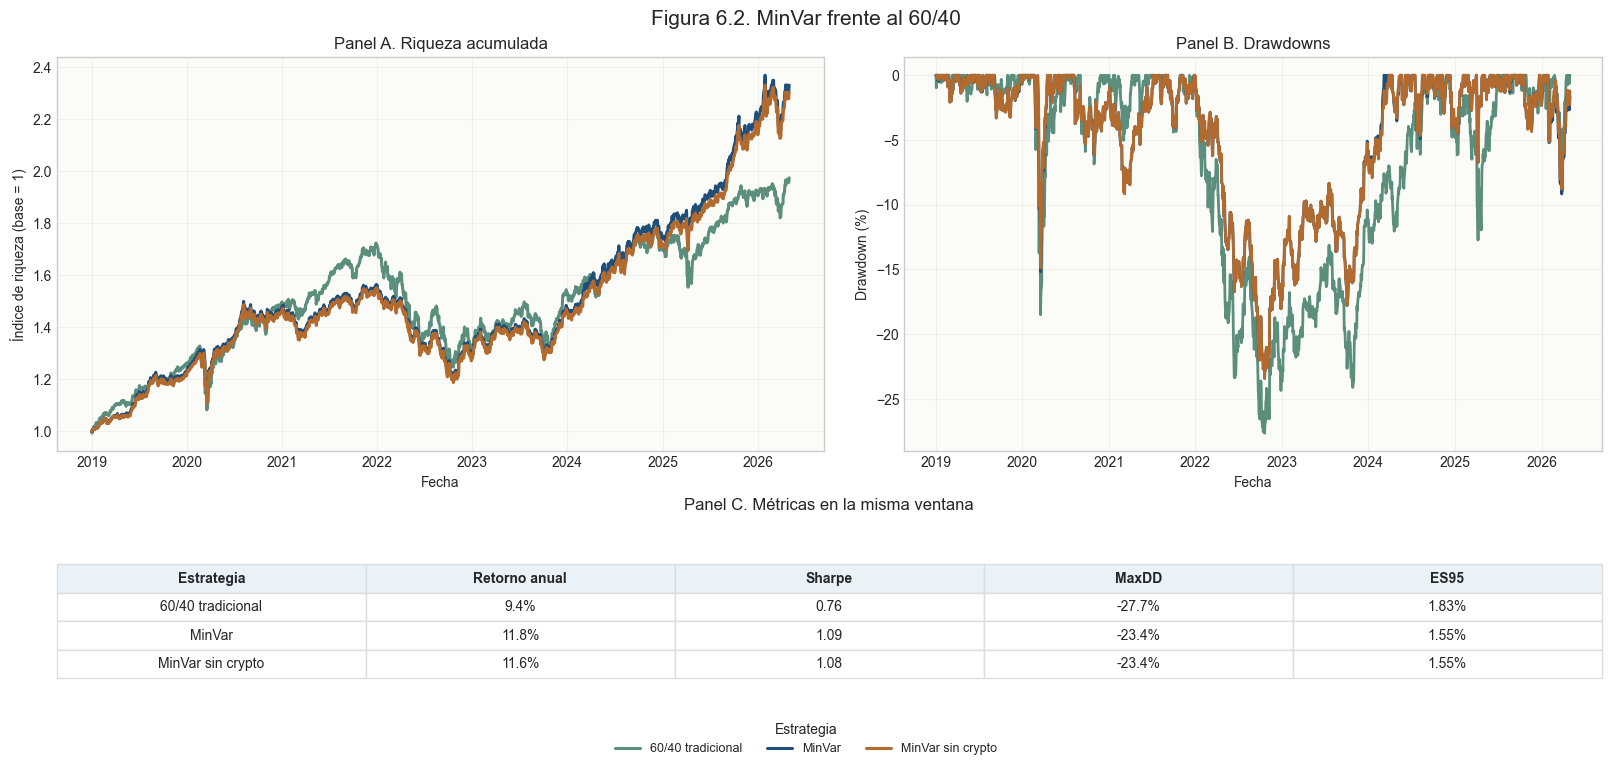

**Qué muestra:** Riqueza, drawdown y métricas resumen de 60/40, MinVar y MinVar sin crypto sobre la ventana común 2019-01-01 a 2026-05-01.  \n**Qué se observa:** MinVar mejora el perfil frente al 60/40, pero MinVar sin crypto queda muy cerca de MinVar en las métricas centrales.  \n**Qué implica:** La figura separa el valor de la construcción MinVar del valor incremental de crypto: si el control sin crypto queda cerca, la mejora no puede atribuirse limpiamente a BTC/ETH.  \n**Limitación:** Las métricas del panel C se recalculan sobre la ventana común para hacer comparables las curvas; pueden diferir ligeramente de tablas con ventanas nativas.

In [423]:
if VIS_COMMON_RETURNS.empty:
    vis_note("No hay suficiente solape temporal entre 60/40 tradicional, MinVar y MinVar sin crypto para construir la Figura 6.2.")
    vis_show_reading(
        "La comparación en ventana común entre 60/40 tradicional, MinVar y MinVar sin crypto.",
        "No puede renderizarse porque falta al menos una de las series diarias necesarias.",
        "Sin ventana común no conviene comparar curvas finales entre estrategias con muestras distintas.",
        "La figura depende de los retornos diarios consolidados del backtest y del overlay.",
    )
else:
    summary_rows = []
    for strategy in VIS_COMMON_RETURNS.columns:
        returns = VIS_COMMON_RETURNS[strategy].dropna()
        wealth = compute_wealth(returns)
        drawdown = compute_drawdown(returns)
        ann_return = wealth.iloc[-1] ** (252 / len(returns)) - 1
        ann_vol = returns.std() * np.sqrt(252)
        sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan
        es95 = -returns[returns <= returns.quantile(0.05)].mean()
        summary_rows.append({
            "Estrategia": strategy,
            "Retorno anual": f"{ann_return * 100:.1f}%",
            "Sharpe": f"{sharpe:.2f}",
            "MaxDD": f"{drawdown.min() * 100:.1f}%",
            "ES95": f"{es95 * 100:.2f}%",
        })
    summary_table = pd.DataFrame(summary_rows)

    fig = plt.figure(figsize=(16, 7.2), constrained_layout=True)
    grid = fig.add_gridspec(2, 2, height_ratios=[1.1, 0.56], width_ratios=[1.1, 1.0])
    ax_wealth = fig.add_subplot(grid[0, 0])
    ax_dd = fig.add_subplot(grid[0, 1])
    ax_table = fig.add_subplot(grid[1, :])

    for strategy in VIS_COMMON_WEALTH.columns:
        color = VIS_COLORS.get(strategy, None)
        ax_wealth.plot(VIS_COMMON_WEALTH.index, VIS_COMMON_WEALTH[strategy], linewidth=2.2, color=color, label=strategy)
        ax_dd.plot(VIS_COMMON_DRAWDOWN.index, VIS_COMMON_DRAWDOWN[strategy] * 100.0, linewidth=2.0, color=color, label=strategy)

    ax_wealth.set_title("Panel A. Riqueza acumulada", fontsize=12)
    ax_wealth.set_xlabel("Fecha")
    ax_wealth.set_ylabel("Índice de riqueza (base = 1)")
    ax_wealth.grid(True, alpha=0.25)

    ax_dd.set_title("Panel B. Drawdowns", fontsize=12)
    ax_dd.set_xlabel("Fecha")
    ax_dd.set_ylabel("Drawdown (%)")
    ax_dd.grid(True, alpha=0.25)

    handles, labels = ax_wealth.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.02), ncol=3, frameon=False, title="Estrategia")

    ax_table.axis("off")
    table = ax_table.table(cellText=summary_table.values, colLabels=summary_table.columns, cellLoc="center", colLoc="center", loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.45)
    for row_idx in range(len(summary_table) + 1):
        for col_idx in range(len(summary_table.columns)):
            cell = table[row_idx, col_idx]
            cell.set_edgecolor("#dddddd")
            if row_idx == 0:
                cell.set_facecolor("#eaf2f8")
                cell.set_text_props(weight="bold")
    ax_table.set_title("Panel C. Métricas en la misma ventana", fontsize=12, pad=8)

    fig.suptitle("Figura 6.2. MinVar frente al 60/40", fontsize=15)
    plt.show()

    vis_show_reading(
        f"Riqueza, drawdown y métricas resumen de 60/40, MinVar y MinVar sin crypto sobre la ventana común {VIS_COMMON_RETURNS.index.min().date()} a {VIS_COMMON_RETURNS.index.max().date()}.",
        "MinVar mejora el perfil frente al 60/40, pero MinVar sin crypto queda muy cerca de MinVar en las métricas centrales.",
        "La figura separa el valor de la construcción MinVar del valor incremental de crypto: si el control sin crypto queda cerca, la mejora no puede atribuirse limpiamente a BTC/ETH.",
        "Las métricas del panel C se recalculan sobre la ventana común para hacer comparables las curvas; pueden diferir ligeramente de tablas con ventanas nativas.",
    )

### Figura 6.3 — Efecto incremental de crypto

**Pregunta de investigación.** ¿Permitir BTC/ETH añade una mejora material y robusta frente al mismo MinVar sin crypto?

**Cómo se implementó**
- Código principal: `src/robustness.py`, `src/bootstrap.py`
- Script: `scripts/run_robustness.py`, `scripts/run_statistical_confidence.py`
- Outputs usados: `outputs/chapter5/overlay_backtest_summary.csv`, `data/processed/robustness/confidence_summary.csv`
- Qué contrasta: deltas MinVar menos MinVar sin crypto, intervalo bootstrap y exposición efectiva.
- Qué permite concluir: si crypto aporta algo material, estadísticamente robusto y acompañado de peso económico relevante.

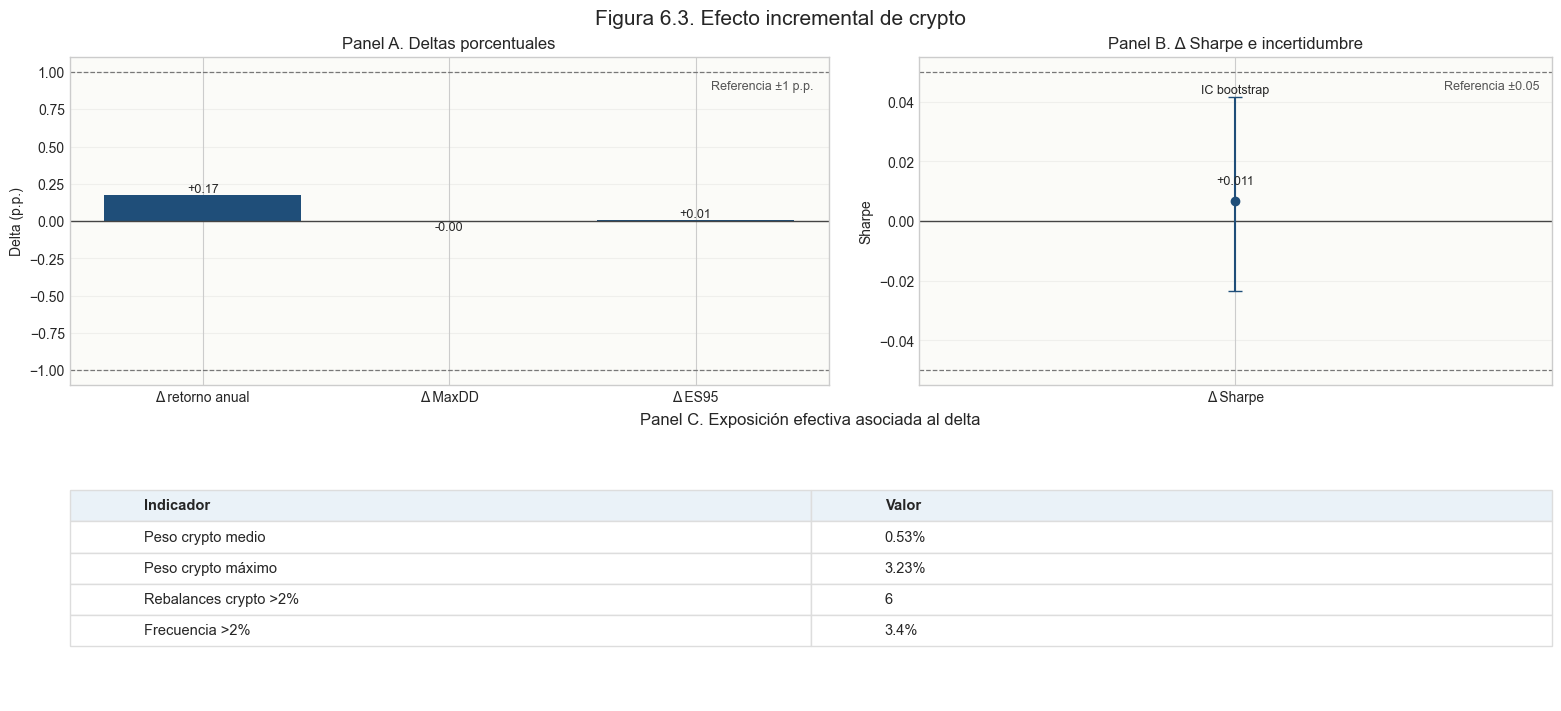

**Qué muestra:** Deltas de retorno, drawdown, ES95, Sharpe e intensidad efectiva de la exposición crypto.  \n**Qué se observa:** El delta de Sharpe es pequeño y el intervalo bootstrap incluye cero. La exposición media a crypto es 0.53% y rara vez supera el 2%.  \n**Qué implica:** Una diferencia positiva pequeña no basta: para afirmar que crypto aporta tendría que ser material, robusta y acompañada de exposición económicamente relevante.  \n**Limitación:** Los umbrales ±0.05 Sharpe y ±1 p.p. de retorno son referencias de lectura, no tests estadísticos formales.

In [424]:
if VIS_BASELINE_ROW.empty or VIS_NO_CRYPTO_ROW.empty:
    vis_note("No se encuentran simultáneamente MinVar y MinVar sin crypto en `overlay_backtest_summary.csv`.")
    vis_show_reading(
        "Los deltas de rendimiento, riesgo y exposición entre MinVar y el control sin crypto.",
        "La figura no puede cuantificarse porque falta al menos una de las filas resumen necesarias.",
        "Sin el control explícito la atribución del efecto crypto queda incompleta.",
        "La comparación depende de la tabla resumen neta del capítulo de overlay.",
    )
else:
    delta_metrics = pd.DataFrame([
        ["Δ retorno anual", (vis_metric(VIS_BASELINE_ROW, "ann_return", "annualized_return") - vis_metric(VIS_NO_CRYPTO_ROW, "ann_return", "annualized_return")) * 100.0, "p.p.", 1.0],
        ["Δ MaxDD", (vis_metric(VIS_BASELINE_ROW, "max_drawdown") - vis_metric(VIS_NO_CRYPTO_ROW, "max_drawdown")) * 100.0, "p.p.", np.nan],
        ["Δ ES95", (vis_metric(VIS_BASELINE_ROW, "es95", "expected_shortfall_net") - vis_metric(VIS_NO_CRYPTO_ROW, "es95", "expected_shortfall_net")) * 100.0, "p.p.", np.nan],
    ], columns=["Métrica", "Valor", "Unidad", "Materialidad"])

    delta_sharpe = vis_metric(VIS_BASELINE_ROW, "sharpe") - vis_metric(VIS_NO_CRYPTO_ROW, "sharpe")
    avg_crypto = vis_metric(VIS_BASELINE_ROW, "avg_crypto_weight", "crypto_avg_weight")
    max_crypto = vis_metric(VIS_BASELINE_ROW, "max_crypto_weight", "crypto_max_weight")
    n_gt2 = vis_metric(VIS_BASELINE_ROW, "n_rebalances_crypto_gt_2pct", "n_crypto_rebalances_gt_2pct")
    n_rebalances = len(VIS_CRYPTO_PANEL.loc[VIS_CRYPTO_PANEL["Estrategia"] == "MinVar"]) if not VIS_CRYPTO_PANEL.empty else np.nan
    share_gt2 = n_gt2 / n_rebalances if pd.notna(n_gt2) and pd.notna(n_rebalances) and n_rebalances else np.nan

    anchor = pd.DataFrame()
    if VIS_CONFIDENCE is not None and not VIS_CONFIDENCE.empty and "comparison_id" in VIS_CONFIDENCE.columns:
        anchor = VIS_CONFIDENCE.loc[VIS_CONFIDENCE["comparison_id"] == "C1_anchor_pair"]

    fig = plt.figure(figsize=(15.5, 7.0), constrained_layout=True)
    grid = fig.add_gridspec(2, 2, height_ratios=[1.05, 0.85], width_ratios=[1.2, 1.0])
    ax_delta = fig.add_subplot(grid[0, 0])
    ax_sharpe = fig.add_subplot(grid[0, 1])
    ax_expo = fig.add_subplot(grid[1, :])

    bars = ax_delta.bar(delta_metrics["Métrica"], delta_metrics["Valor"], color=["#1f4e79" if value >= 0 else "#c84c09" for value in delta_metrics["Valor"]])
    ax_delta.axhline(0, color="#444444", linewidth=1.0)
    ax_delta.axhline(1.0, color="#777777", linestyle="--", linewidth=0.9)
    ax_delta.axhline(-1.0, color="#777777", linestyle="--", linewidth=0.9)
    ax_delta.set_title("Panel A. Deltas porcentuales", fontsize=12)
    ax_delta.set_ylabel("Delta (p.p.)")
    ax_delta.grid(True, axis="y", alpha=0.25)
    ax_delta.text(0.98, 0.93, "Referencia ±1 p.p.", transform=ax_delta.transAxes, ha="right", va="top", fontsize=9, color="#555555")
    for bar, raw_value in zip(bars, delta_metrics["Valor"]):
        ax_delta.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{raw_value:+.2f}", ha="center", va="bottom" if raw_value >= 0 else "top", fontsize=9)

    ax_sharpe.axhline(0, color="#444444", linewidth=1.0)
    ax_sharpe.axhline(0.05, color="#777777", linestyle="--", linewidth=0.9)
    ax_sharpe.axhline(-0.05, color="#777777", linestyle="--", linewidth=0.9)
    ax_sharpe.set_xlim(-0.7, 0.7)
    ax_sharpe.set_xticks([0], ["Δ Sharpe"])
    ax_sharpe.set_title("Panel B. Δ Sharpe e incertidumbre", fontsize=12)
    ax_sharpe.set_ylabel("Sharpe")
    ax_sharpe.grid(True, axis="y", alpha=0.25)
    if not anchor.empty:
        row = anchor.iloc[0]
        point = float(row["point_estimate_difference"])
        lower = float(row["ci_lower"])
        upper = float(row["ci_upper"])
        ax_sharpe.errorbar([0], [point], yerr=[[point - lower], [upper - point]], fmt="o", color="#1f4e79", capsize=5, linewidth=1.5)
        ax_sharpe.text(0, upper, "IC bootstrap", ha="center", va="bottom", fontsize=9)
    else:
        ax_sharpe.bar([0], [delta_sharpe], color="#1f4e79")
    ax_sharpe.text(0, delta_sharpe, f"{delta_sharpe:+.3f}", ha="center", va="bottom" if delta_sharpe >= 0 else "top", fontsize=9)
    ax_sharpe.text(0.98, 0.93, "Referencia ±0.05", transform=ax_sharpe.transAxes, ha="right", va="top", fontsize=9, color="#555555")

    expo_table = pd.DataFrame([
        ["Peso crypto medio", f"{avg_crypto * 100:.2f}%"],
        ["Peso crypto máximo", f"{max_crypto * 100:.2f}%"],
        ["Rebalances crypto >2%", f"{int(n_gt2) if pd.notna(n_gt2) else 'n/d'}"],
        ["Frecuencia >2%", f"{share_gt2 * 100:.1f}%" if pd.notna(share_gt2) else "n/d"],
    ], columns=["Indicador", "Valor"])
    ax_expo.axis("off")
    table = ax_expo.table(cellText=expo_table.values, colLabels=expo_table.columns, cellLoc="left", colLoc="left", loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(10.5)
    table.scale(1, 1.55)
    for row_idx in range(len(expo_table) + 1):
        for col_idx in range(len(expo_table.columns)):
            cell = table[row_idx, col_idx]
            cell.set_edgecolor("#dddddd")
            if row_idx == 0:
                cell.set_facecolor("#eaf2f8")
                cell.set_text_props(weight="bold")
    ax_expo.set_title("Panel C. Exposición efectiva asociada al delta", fontsize=12, pad=8)

    fig.suptitle("Figura 6.3. Efecto incremental de crypto", fontsize=15)
    plt.show()

    obs_text = "El delta de Sharpe es pequeño y el intervalo bootstrap incluye cero." if not anchor.empty and bool(anchor.iloc[0]["ci_includes_zero"]) else "Las diferencias son pequeñas incluso cuando el signo favorece a la versión con crypto."
    vis_show_reading(
        "Deltas de retorno, drawdown, ES95, Sharpe e intensidad efectiva de la exposición crypto.",
        obs_text + f" La exposición media a crypto es {avg_crypto * 100:.2f}% y rara vez supera el 2%.",
        "Una diferencia positiva pequeña no basta: para afirmar que crypto aporta tendría que ser material, robusta y acompañada de exposición económicamente relevante.",
        "Los umbrales ±0.05 Sharpe y ±1 p.p. de retorno son referencias de lectura, no tests estadísticos formales.",
    )

### Figura 6.4 — Exposición crypto: estructural o táctica

**Pregunta de investigación.** ¿La asignación a BTC/ETH aparece como exposición persistente y material, o como uso intermitente de baja intensidad?

**Cómo se implementó**
- Código principal: `src/backtest.py`, `src/optimizer.py`
- Script: `scripts/run_backtest.py`
- Outputs usados: `data/processed/weights_history.csv`, `outputs/chapter5/overlay_backtest_summary.csv`
- Qué contrasta: peso total BTC+ETH de MinVar por rebalanceo, distribución por buckets y estadísticos de exposición.
- Qué permite concluir: si crypto se comporta como asignación estructural o como exposición táctica.

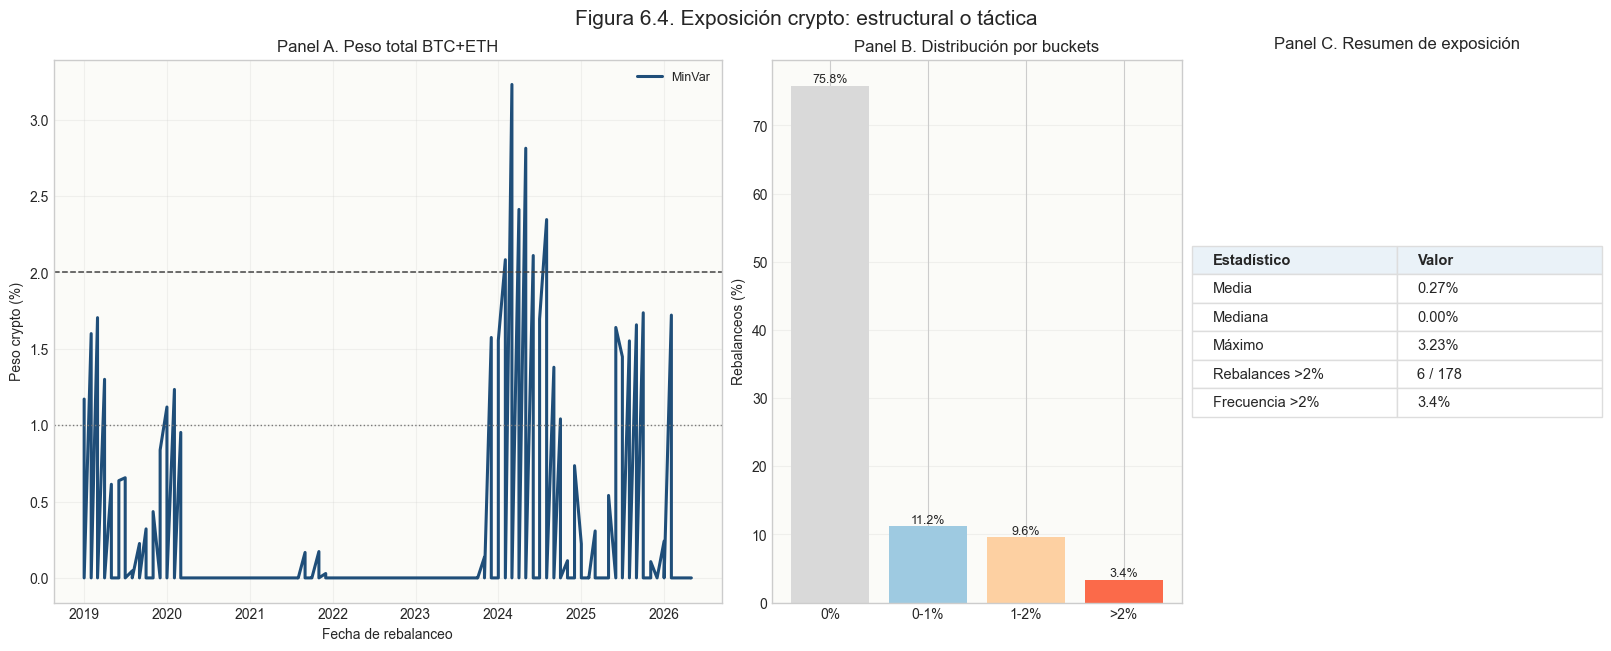

**Qué muestra:** La senda temporal del peso total BTC+ETH de MinVar, su distribución por buckets y un resumen estadístico compacto.  \n**Qué se observa:** La exposición media es 0.27%, la mediana es 0.00% y solo supera 2% en 3.4% de rebalanceos.  \n**Qué implica:** Una asignación estructural debería aparecer de forma frecuente y material; la evidencia muestra pesos bajos e intermitentes.  \n**Limitación:** La figura se centra solo en MinVar para no mezclar exposición base, CVaR, overlay y regímenes en una misma lectura.

In [425]:
minvar_crypto = pd.DataFrame()
if VIS_CRYPTO_PANEL is not None and not VIS_CRYPTO_PANEL.empty:
    minvar_crypto = VIS_CRYPTO_PANEL.loc[VIS_CRYPTO_PANEL["Estrategia"] == "MinVar"].sort_values("rebalance_date").copy()

if minvar_crypto.empty:
    vis_note("No hay panel consolidado de pesos MinVar para construir la Figura 6.4.")
    vis_show_reading(
        "La evolución temporal, distribución y resumen estadístico de la exposición total a BTC y ETH.",
        "La figura no puede renderizarse porque faltan historiales de pesos MinVar.",
        "Sin pesos por rebalanceo no puede evaluarse si crypto es estructural o solo táctica.",
        "La visual depende de `weights_history` y de la consolidación de pesos crypto.",
    )
else:
    focus = minvar_crypto["crypto_total"].astype(float)
    bucket_df = minvar_crypto.copy()
    bucket_df["Tramo"] = pd.cut(
        bucket_df["crypto_total"],
        bins=[-1e-12, 1e-8, 0.01, 0.02, 1.0],
        labels=["0%", "0-1%", "1-2%", ">2%"],
        include_lowest=True,
    )
    bucket_share = bucket_df["Tramo"].value_counts(normalize=True).reindex(["0%", "0-1%", "1-2%", ">2%"], fill_value=0.0)
    exposure_stats = pd.DataFrame([
        ["Media", f"{focus.mean() * 100:.2f}%"],
        ["Mediana", f"{focus.median() * 100:.2f}%"],
        ["Máximo", f"{focus.max() * 100:.2f}%"],
        ["Rebalances >2%", f"{(focus > 0.02).sum()} / {len(focus)}"],
        ["Frecuencia >2%", f"{(focus > 0.02).mean() * 100:.1f}%"],
    ], columns=["Estadístico", "Valor"])

    fig = plt.figure(figsize=(16, 6.4), constrained_layout=True)
    grid = fig.add_gridspec(1, 3, width_ratios=[1.55, 0.95, 0.95])
    ax_time = fig.add_subplot(grid[0, 0])
    ax_bucket = fig.add_subplot(grid[0, 1])
    ax_table = fig.add_subplot(grid[0, 2])

    ax_time.plot(minvar_crypto["rebalance_date"], minvar_crypto["crypto_total"] * 100.0, linewidth=2.2, color=VIS_COLORS.get("MinVar"), label="MinVar")
    ax_time.axhline(1.0, color="#777777", linestyle=":", linewidth=1.0)
    ax_time.axhline(2.0, color="#444444", linestyle="--", linewidth=1.1)
    ax_time.set_title("Panel A. Peso total BTC+ETH", fontsize=12)
    ax_time.set_xlabel("Fecha de rebalanceo")
    ax_time.set_ylabel("Peso crypto (%)")
    ax_time.grid(True, alpha=0.25)
    ax_time.legend(frameon=False)

    bucket_colors = ["#d9d9d9", "#9ecae1", "#fdd0a2", "#fb6a4a"]
    bars = ax_bucket.bar(bucket_share.index.astype(str), bucket_share.values * 100.0, color=bucket_colors)
    ax_bucket.set_title("Panel B. Distribución por buckets", fontsize=12)
    ax_bucket.set_ylabel("Rebalanceos (%)")
    ax_bucket.grid(True, axis="y", alpha=0.25)
    for bar, value in zip(bars, bucket_share.values):
        ax_bucket.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{value * 100:.1f}%", ha="center", va="bottom", fontsize=9)

    ax_table.axis("off")
    table = ax_table.table(cellText=exposure_stats.values, colLabels=exposure_stats.columns, cellLoc="left", colLoc="left", loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(10.5)
    table.scale(1.0, 1.55)
    for row_idx in range(len(exposure_stats) + 1):
        for col_idx in range(len(exposure_stats.columns)):
            cell = table[row_idx, col_idx]
            cell.set_edgecolor("#dddddd")
            if row_idx == 0:
                cell.set_facecolor("#eaf2f8")
                cell.set_text_props(weight="bold")
    ax_table.set_title("Panel C. Resumen de exposición", fontsize=12, pad=8)

    fig.suptitle("Figura 6.4. Exposición crypto: estructural o táctica", fontsize=15)
    plt.show()

    vis_show_reading(
        "La senda temporal del peso total BTC+ETH de MinVar, su distribución por buckets y un resumen estadístico compacto.",
        f"La exposición media es {focus.mean() * 100:.2f}%, la mediana es {focus.median() * 100:.2f}% y solo supera 2% en {(focus > 0.02).mean() * 100:.1f}% de rebalanceos.",
        "Una asignación estructural debería aparecer de forma frecuente y material; la evidencia muestra pesos bajos e intermitentes.",
        "La figura se centra solo en MinVar para no mezclar exposición base, CVaR, overlay y regímenes en una misma lectura.",
    )

### Figura 6.5 — Robustez de la tesis crypto

**Pregunta de investigación.** ¿La conclusión sobre crypto depende de un supuesto concreto, o se mantiene al cambiar ventanas, costes, topes y especificaciones?

**Cómo se implementó**
- Código principal: `src/robustness.py`, `src/bootstrap.py`
- Script: `scripts/run_robustness.py`, `scripts/run_statistical_confidence.py`
- Outputs usados: `data/processed/robustness/robustness_summary_common_family_net.csv`, `data/processed/robustness/confidence_summary.csv`
- Qué contrasta: MinVar vs MinVar sin crypto por familia de robustez, deltas netos y sensibilidad a costes.
- Qué permite concluir: si el claim crypto sobrevive a cambios razonables de supuestos.

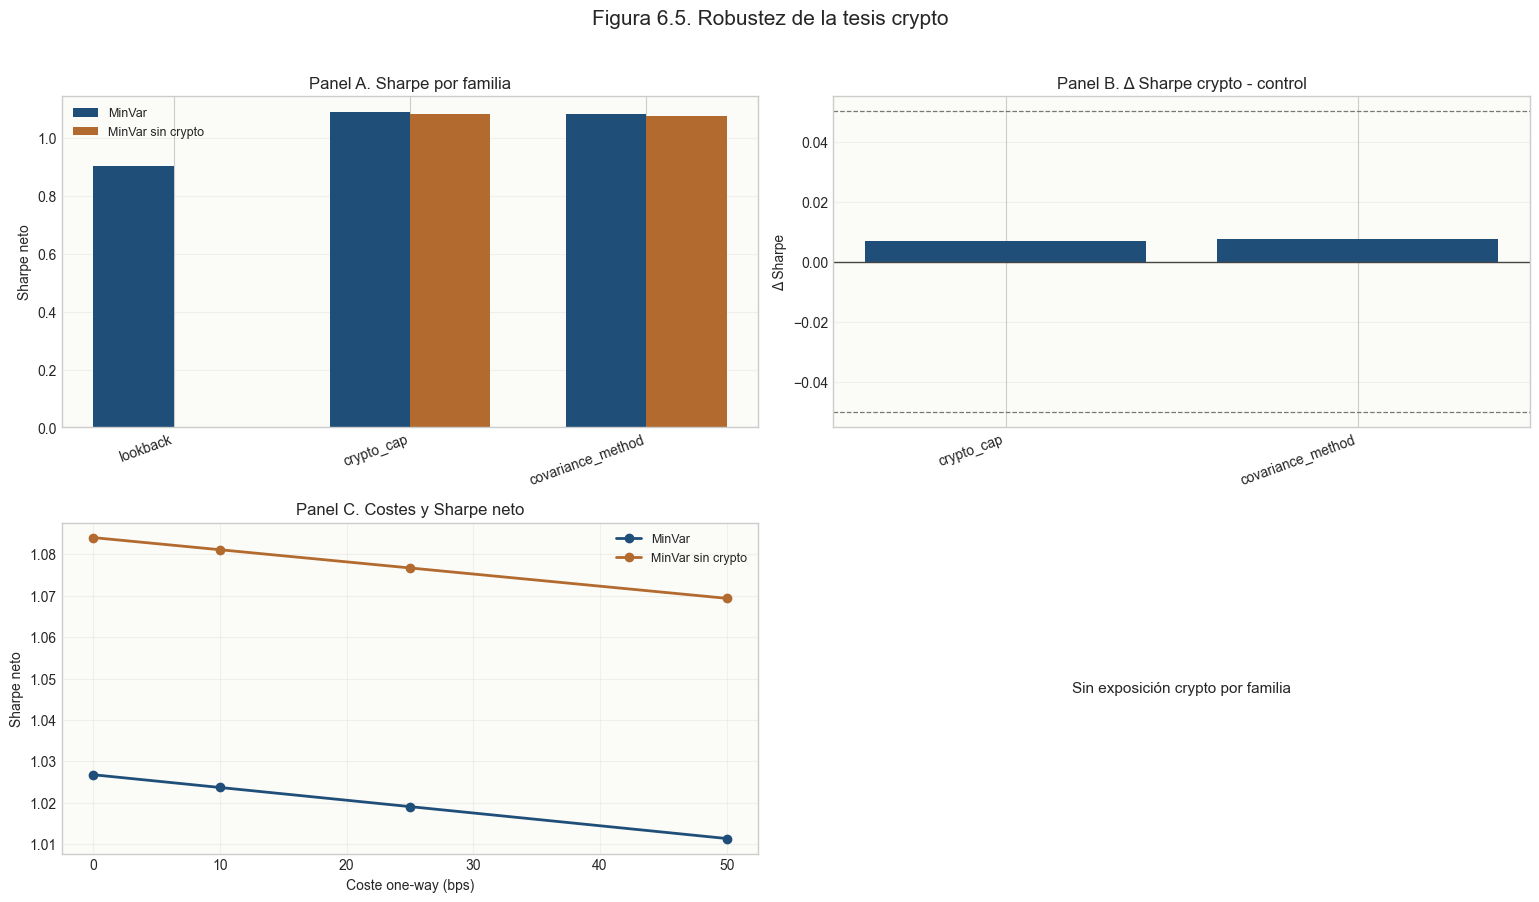

**Qué muestra:** Sharpe de MinVar y MinVar sin crypto por familia, delta de Sharpe, sensibilidad a costes y exposición crypto media.  \n**Qué se observa:** Los deltas frente al control son pequeños frente a la referencia de materialidad; el mayor |Δ Sharpe| por familia es 0.007.  \n**Qué implica:** La robustez apoya el framework MinVar, pero no una contribución crypto fuerte y estable.  \n**Limitación:** La agregación por familia resume varias especificaciones; los detalles finos permanecen en el notebook de robustez.

In [426]:
if VIS_ROBUSTNESS is None or VIS_ROBUSTNESS.empty:
    vis_note("No está disponible `robustness_summary_common_family_net.csv`.")
    vis_show_reading(
        "La comparación MinVar vs MinVar sin crypto por familias de robustez.",
        "La figura no puede construirse porque falta la tabla consolidada de robustez en ventana común.",
        "Sin esta capa no puede evaluarse cuán estable es la mejora atribuida a crypto.",
        "La lectura depende del resumen neto por familias del bloque de robustez.",
    )
else:
    rob = VIS_ROBUSTNESS.copy()
    rob["Estrategia"] = np.where(rob["max_total_crypto_weight"].astype(float).gt(0), "MinVar", "MinVar sin crypto")
    family_order = [fam for fam in ["lookback", "crypto_cap", "covariance_method", "rebalance_frequency", "cost_sensitivity"] if fam in rob["family"].unique()]
    if not family_order:
        family_order = sorted(rob["family"].dropna().unique())

    family_summary = rob.loc[rob["Estrategia"].isin(["MinVar", "MinVar sin crypto"])].groupby(["family", "Estrategia"], as_index=False).agg(
        sharpe_net=("sharpe_net", "mean"),
        ann_return_net=("ann_return_net", "mean") if "ann_return_net" in rob.columns else ("sharpe_net", "mean"),
    )
    family_pivot = family_summary.pivot(index="family", columns="Estrategia", values="sharpe_net").reindex(family_order)
    delta_family = (family_pivot.get("MinVar") - family_pivot.get("MinVar sin crypto")).dropna()

    cost_pivot = pd.DataFrame()
    if "cost_bps" in rob.columns:
        costs = rob.loc[rob["max_total_crypto_weight"].isin([0.0, 0.2])].copy()
        costs["Estrategia"] = costs["max_total_crypto_weight"].map({0.2: "MinVar", 0.0: "MinVar sin crypto"})
        cost_pivot = costs.pivot_table(index="cost_bps", columns="Estrategia", values="sharpe_net", aggfunc="mean").sort_index()

    crypto_exposure_family = pd.DataFrame()
    crypto_metric = None
    for candidate in ["avg_crypto_weight", "crypto_avg_weight", "mean_crypto_weight"]:
        if candidate in rob.columns:
            crypto_metric = candidate
            break
    if crypto_metric:
        crypto_exposure_family = rob.loc[rob["max_total_crypto_weight"].astype(float).gt(0)].groupby("family", as_index=False)[crypto_metric].mean()
        crypto_exposure_family = crypto_exposure_family.set_index("family").reindex(family_order).reset_index()

    fig, axes = plt.subplots(2, 2, figsize=(15.5, 8.8))

    x = np.arange(len(family_order))
    width = 0.34
    for idx, strategy in enumerate(["MinVar", "MinVar sin crypto"]):
        vals = family_pivot[strategy].reindex(family_order) if strategy in family_pivot.columns else pd.Series(index=family_order, dtype=float)
        axes[0, 0].bar(x + (idx - 0.5) * width, vals, width=width, color=VIS_COLORS.get(strategy), label=strategy)
    axes[0, 0].set_xticks(x, family_order, rotation=20, ha="right")
    axes[0, 0].set_title("Panel A. Sharpe por familia", fontsize=12)
    axes[0, 0].set_ylabel("Sharpe neto")
    axes[0, 0].grid(True, axis="y", alpha=0.25)
    axes[0, 0].legend(frameon=False)

    axes[0, 1].bar(delta_family.index, delta_family.values, color=["#1f4e79" if v >= 0 else "#c84c09" for v in delta_family.values])
    axes[0, 1].axhline(0, color="#444444", linewidth=1.0)
    axes[0, 1].axhline(0.05, color="#777777", linestyle="--", linewidth=0.9)
    axes[0, 1].axhline(-0.05, color="#777777", linestyle="--", linewidth=0.9)
    axes[0, 1].set_xticks(np.arange(len(delta_family.index)), delta_family.index, rotation=20, ha="right")
    axes[0, 1].set_title("Panel B. Δ Sharpe crypto - control", fontsize=12)
    axes[0, 1].set_ylabel("Δ Sharpe")
    axes[0, 1].grid(True, axis="y", alpha=0.25)

    if cost_pivot.empty or not {"MinVar", "MinVar sin crypto"}.issubset(cost_pivot.columns):
        axes[1, 0].text(0.5, 0.5, "Sin sensibilidad comparable a costes", ha="center", va="center", fontsize=11)
        axes[1, 0].axis("off")
    else:
        for strategy in ["MinVar", "MinVar sin crypto"]:
            axes[1, 0].plot(cost_pivot.index, cost_pivot[strategy], marker="o", linewidth=2.0, color=VIS_COLORS.get(strategy), label=strategy)
        axes[1, 0].set_title("Panel C. Costes y Sharpe neto", fontsize=12)
        axes[1, 0].set_xlabel("Coste one-way (bps)")
        axes[1, 0].set_ylabel("Sharpe neto")
        axes[1, 0].grid(True, alpha=0.25)
        axes[1, 0].legend(frameon=False)

    if crypto_exposure_family.empty:
        axes[1, 1].text(0.5, 0.5, "Sin exposición crypto por familia", ha="center", va="center", fontsize=11)
        axes[1, 1].axis("off")
    else:
        axes[1, 1].bar(crypto_exposure_family["family"], crypto_exposure_family[crypto_metric] * 100.0, color="#b36a2e")
        axes[1, 1].set_xticks(np.arange(len(crypto_exposure_family)), crypto_exposure_family["family"], rotation=20, ha="right")
        axes[1, 1].set_title("Panel D. Peso crypto medio por familia", fontsize=12)
        axes[1, 1].set_ylabel("Peso medio (%)")
        axes[1, 1].grid(True, axis="y", alpha=0.25)

    fig.suptitle("Figura 6.5. Robustez de la tesis crypto", fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()

    max_abs_delta = delta_family.abs().max() if not delta_family.empty else np.nan
    vis_show_reading(
        "Sharpe de MinVar y MinVar sin crypto por familia, delta de Sharpe, sensibilidad a costes y exposición crypto media.",
        f"Los deltas frente al control son pequeños frente a la referencia de materialidad; el mayor |Δ Sharpe| por familia es {max_abs_delta:.3f}." if pd.notna(max_abs_delta) else "No hay deltas comparables suficientes por familia.",
        "La robustez apoya el framework MinVar, pero no una contribución crypto fuerte y estable.",
        "La agregación por familia resume varias especificaciones; los detalles finos permanecen en el notebook de robustez.",
    )

### Figura 6.6 — CVaR y riesgo de cola

**Pregunta de investigación.** ¿Optimizar pérdidas extremas mejora de forma clara ES95 y MaxDD frente a MinVar y cambia la tesis sobre crypto?

**Cómo se implementó**
- Código principal: `src/cvar_optimizer.py`, `src/stress.py`
- Script: `scripts/run_tail_risk.py`
- Outputs usados: `data/processed/tail_risk/tail_risk_summary_net.csv`, `data/processed/tail_risk/stress_summary.csv`
- Qué contrasta: MinVar, MinVar sin crypto, CVaR y CVaR sin crypto en retorno, ES95, drawdown y deltas CVaR - MinVar.
- Qué permite concluir: si el objetivo de cola domina económicamente o solo aporta un ángulo diagnóstico.

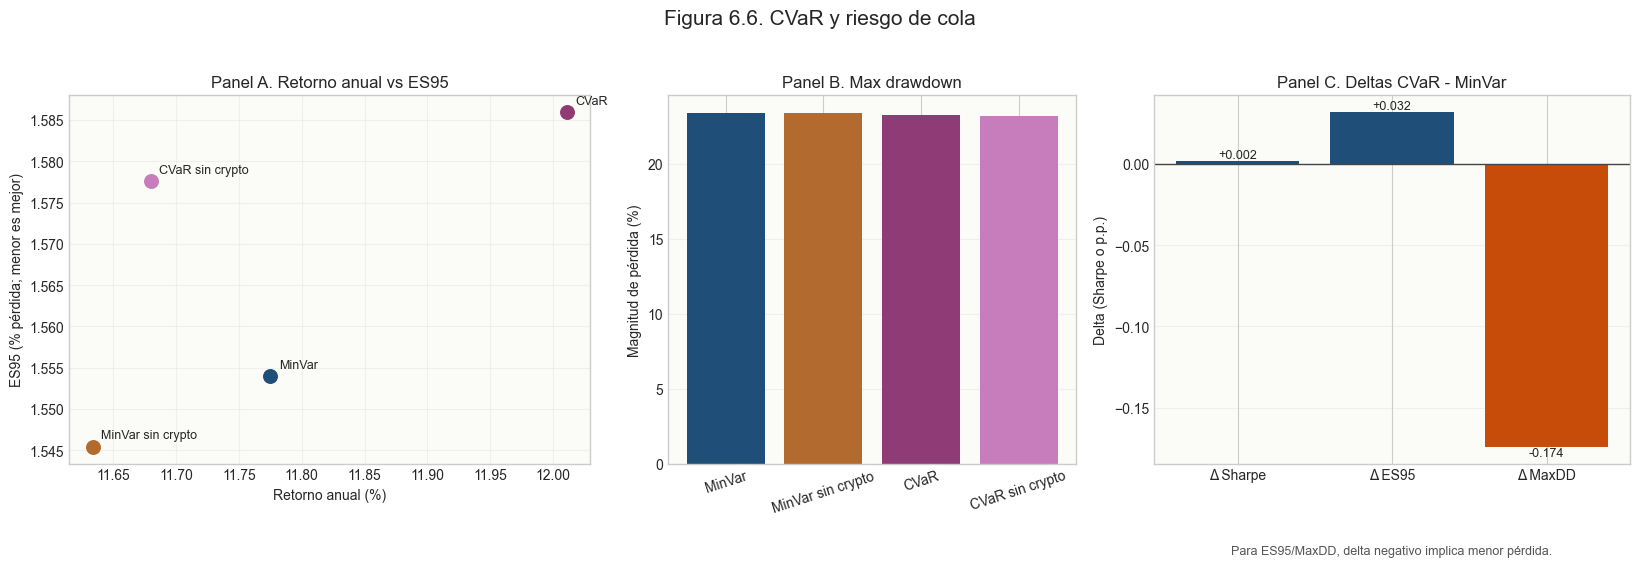

**Qué muestra:** Retorno frente a ES95, magnitud de MaxDD y deltas CVaR - MinVar con dirección económica explícita.  \n**Qué se observa:** CVaR entrega Sharpe neto 1.095 frente a 1.093 en MinVar, con ES95 de 1.59% frente a 1.55%.  \n**Qué implica:** CVaR es una prueba de riesgo de cola; si no mejora claramente ES95/MaxDD frente a MinVar, no rescata la tesis crypto.  \n**Limitación:** ES95 se muestra como magnitud positiva de pérdida; en ese eje menor es mejor, no mayor.

In [427]:
if VIS_TAIL_NET is None or VIS_TAIL_NET.empty:
    vis_note("No está disponible `tail_risk_summary_net.csv`.")
    vis_show_reading(
        "La comparación entre MinVar y CVaR en retorno, cola y drawdown.",
        "La figura no puede renderizarse porque falta el resumen neto de tail risk.",
        "Sin esta tabla no puede evaluarse si CVaR domina o no a MinVar.",
        "La visual depende del resumen neto y de `stress_summary.csv` para estrés.",
    )
else:
    tail = VIS_TAIL_NET.copy()
    tail["Estrategia"] = tail["strategy"].map(vis_h_strategy)
    ordered = ["MinVar", "MinVar sin crypto", "CVaR", "CVaR sin crypto"]
    tail = tail.loc[tail["Estrategia"].isin(ordered)].copy()
    tail["order"] = tail["Estrategia"].map({name: idx for idx, name in enumerate(ordered)})
    tail = tail.sort_values("order")

    cvar_row = vis_pick_row(VIS_TAIL_NET, "strategy", "cvar_baseline")
    minvar_row = vis_pick_row(VIS_TAIL_NET, "strategy", "minvar_baseline_ch1")
    delta_table = pd.DataFrame()
    if not cvar_row.empty and not minvar_row.empty:
        delta_table = pd.DataFrame([
            ["Δ Sharpe", vis_metric(cvar_row, "sharpe_net") - vis_metric(minvar_row, "sharpe_net"), "más alto es mejor"],
            ["Δ ES95", (vis_metric(cvar_row, "expected_shortfall_net") - vis_metric(minvar_row, "expected_shortfall_net")) * 100.0, "menor pérdida es mejor"],
            ["Δ MaxDD", (abs(vis_metric(cvar_row, "max_drawdown_net")) - abs(vis_metric(minvar_row, "max_drawdown_net"))) * 100.0, "menor pérdida es mejor"],
        ], columns=["Métrica", "Delta", "Dirección"])

    fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.6), gridspec_kw={"width_ratios": [1.15, 0.9, 1.05]})

    for row in tail.itertuples():
        axes[0].scatter(row.ann_return_net * 100.0, row.expected_shortfall_net * 100.0, s=95, color=VIS_COLORS.get(row.Estrategia), label=row.Estrategia)
        axes[0].annotate(row.Estrategia, (row.ann_return_net * 100.0, row.expected_shortfall_net * 100.0), textcoords="offset points", xytext=(6, 6), fontsize=9)
    axes[0].set_title("Panel A. Retorno anual vs ES95", fontsize=12)
    axes[0].set_xlabel("Retorno anual (%)")
    axes[0].set_ylabel("ES95 (% pérdida; menor es mejor)")
    axes[0].grid(True, alpha=0.25)

    dd_plot = tail[["Estrategia", "max_drawdown_net"]].copy()
    dd_plot["Magnitud MaxDD"] = dd_plot["max_drawdown_net"].abs() * 100.0
    axes[1].bar(dd_plot["Estrategia"], dd_plot["Magnitud MaxDD"], color=[VIS_COLORS.get(name) for name in dd_plot["Estrategia"]])
    axes[1].set_title("Panel B. Max drawdown", fontsize=12)
    axes[1].set_ylabel("Magnitud de pérdida (%)")
    axes[1].tick_params(axis="x", rotation=18)
    axes[1].grid(True, axis="y", alpha=0.25)

    if delta_table.empty:
        axes[2].text(0.5, 0.5, "Sin deltas CVaR-MinVar", ha="center", va="center", fontsize=11)
        axes[2].axis("off")
    else:
        colors = ["#1f4e79" if value >= 0 else "#c84c09" for value in delta_table["Delta"]]
        bars = axes[2].bar(delta_table["Métrica"], delta_table["Delta"], color=colors)
        axes[2].axhline(0, color="#444444", linewidth=1.0)
        axes[2].set_title("Panel C. Deltas CVaR - MinVar", fontsize=12)
        axes[2].set_ylabel("Delta (Sharpe o p.p.)")
        axes[2].grid(True, axis="y", alpha=0.25)
        for bar, value in zip(bars, delta_table["Delta"]):
            axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{value:+.3f}" if abs(value) < 1 else f"{value:+.2f}", ha="center", va="bottom" if value >= 0 else "top", fontsize=9)
        axes[2].text(0.5, -0.22, "Para ES95/MaxDD, delta negativo implica menor pérdida.", transform=axes[2].transAxes, ha="center", va="top", fontsize=9, color="#555555")

    fig.suptitle("Figura 6.6. CVaR y riesgo de cola", fontsize=15, y=1.03)
    plt.tight_layout()
    plt.show()

    if not cvar_row.empty and not minvar_row.empty:
        obs_text = (
            f"CVaR entrega Sharpe neto {vis_metric(cvar_row, 'sharpe_net'):.3f} frente a {vis_metric(minvar_row, 'sharpe_net'):.3f} en MinVar, "
            f"con ES95 de {vis_metric(cvar_row, 'expected_shortfall_net') * 100.0:.2f}% frente a {vis_metric(minvar_row, 'expected_shortfall_net') * 100.0:.2f}%."
        )
    else:
        obs_text = "La comparación directa CVaR-MinVar no está completa."
    vis_show_reading(
        "Retorno frente a ES95, magnitud de MaxDD y deltas CVaR - MinVar con dirección económica explícita.",
        obs_text,
        "CVaR es una prueba de riesgo de cola; si no mejora claramente ES95/MaxDD frente a MinVar, no rescata la tesis crypto.",
        "ES95 se muestra como magnitud positiva de pérdida; en ese eje menor es mejor, no mayor.",
    )

### Figura 6.7 — Regímenes de mercado

**Pregunta de investigación.** ¿El contexto histórico de mercado cambia la interpretación de resultados sin convertirse en una señal predictiva?

**Cómo se implementó**
- Código principal: `src/regime_features.py`, `src/regime_detection.py`, `src/regime_evaluation.py`
- Script: `scripts/run_regime_analysis.py`
- Outputs usados: `data/processed/regime_analysis/regime_labels.csv`, `data/processed/regime_analysis/regime_conditional_performance_net.csv`, `data/processed/regime_analysis/regime_crypto_exposure.csv`
- Qué contrasta: cronología/duración de regímenes, performance condicional y exposición crypto por estado.
- Qué permite concluir: si los resultados son dependientes del entorno y si crypto sigue siendo de baja intensidad.

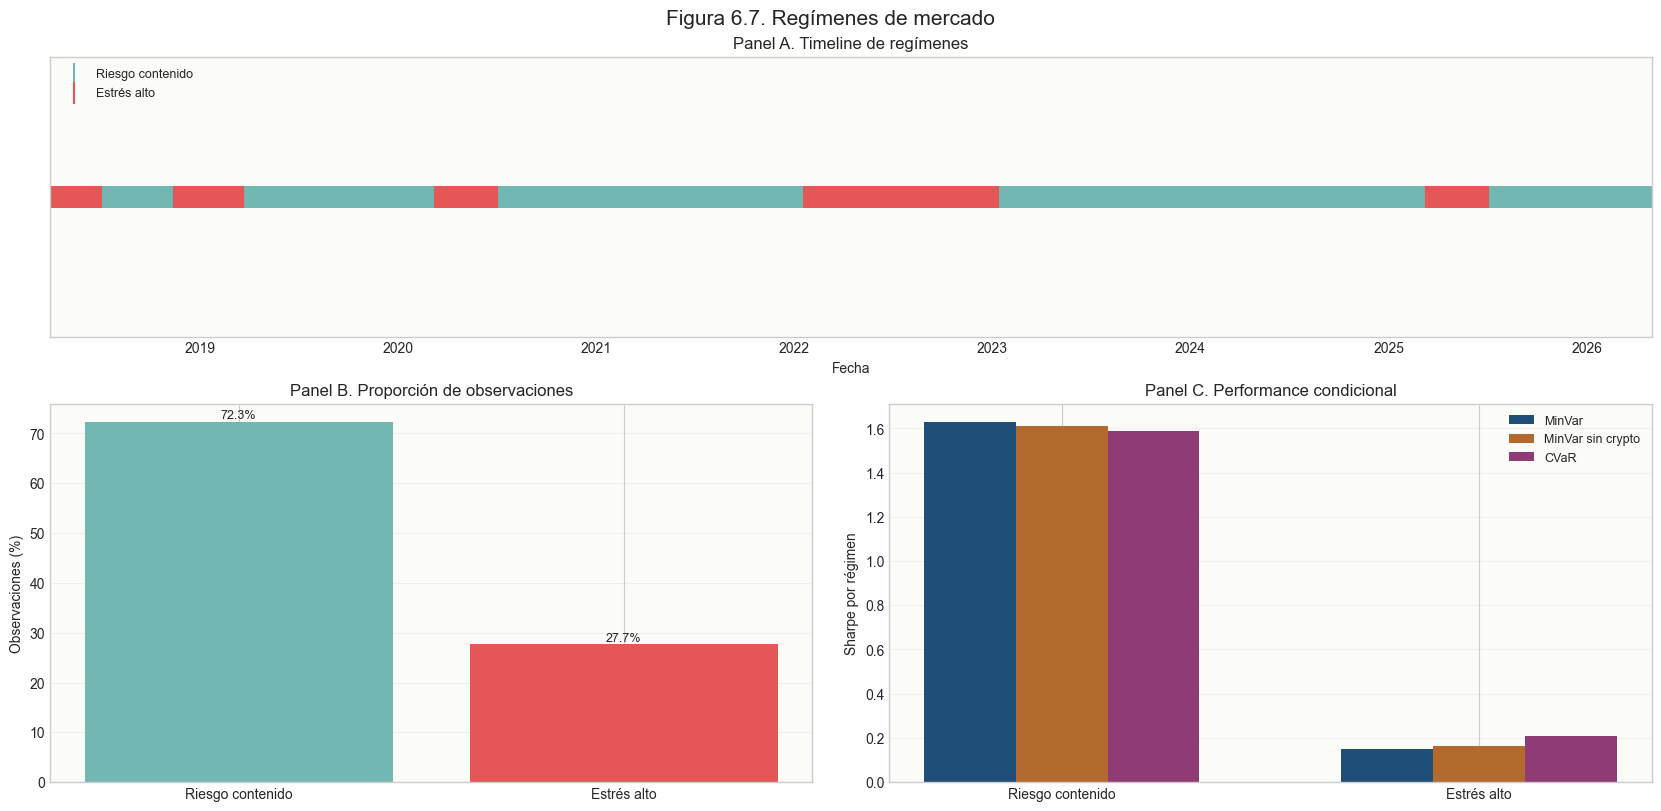

**Qué muestra:** Timeline, duración de regímenes y performance condicional por estado de mercado.  \n**Qué se observa:** El rendimiento cambia de forma marcada entre riesgo contenido y estrés alto. Exposición crypto media MinVar por régimen: Riesgo contenido: 0.60%; Estrés alto: 0.35%.  \n**Qué implica:** Los regímenes muestran contexto histórico, no predicción live validada. La exposición crypto sigue siendo de baja intensidad.  \n**Limitación:** La clasificación de estados depende de la especificación del modelo de regímenes y de la muestra usada.

In [428]:
if (VIS_REGIME_LABELS is None or VIS_REGIME_LABELS.empty) and (VIS_REGIME_PERF is None or VIS_REGIME_PERF.empty):
    vis_note("Faltan `regime_labels.csv` y `regime_conditional_performance_net.csv`.")
    vis_show_reading(
        "La cronología de regímenes y su relación con performance y exposición crypto.",
        "La figura no puede renderizarse porque faltan los outputs básicos del análisis de regímenes.",
        "Sin esta capa solo queda la comparación agregada, sin contexto de entorno.",
        "Los regímenes se tratan aquí como diagnóstico histórico, no como señal operativa.",
    )
else:
    fig = plt.figure(figsize=(16.5, 8.0), constrained_layout=True)
    grid = fig.add_gridspec(2, 2, height_ratios=[0.85, 1.15])
    ax_timeline = fig.add_subplot(grid[0, :])
    ax_duration = fig.add_subplot(grid[1, 0])
    ax_perf = fig.add_subplot(grid[1, 1])

    if VIS_REGIME_LABELS is None or VIS_REGIME_LABELS.empty:
        ax_timeline.text(0.5, 0.5, "Sin cronología de regímenes", ha="center", va="center", fontsize=11)
        ax_timeline.axis("off")
        counts = pd.Series(dtype=float)
    else:
        timeline = VIS_REGIME_LABELS.copy().sort_values("date")
        timeline["Régimen"] = timeline["regime_name"].map(vis_h_regime)
        start_date = timeline["date"].min()
        end_date = timeline["date"].max()
        for regime_name, color in VIS_REGIME_COLORS.items():
            mask = timeline["Régimen"].eq(regime_name)
            ax_timeline.scatter(timeline.loc[mask, "date"], np.zeros(mask.sum()), marker="|", s=260, c=color, label=regime_name)
        ax_timeline.set_xlim(start_date, end_date)
        ax_timeline.set_yticks([])
        ax_timeline.set_title("Panel A. Timeline de regímenes", fontsize=12)
        ax_timeline.set_xlabel("Fecha")
        ax_timeline.legend(frameon=False, loc="upper left")
        ax_timeline.grid(False)
        counts = timeline["Régimen"].value_counts(normalize=True).reindex(["Riesgo contenido", "Estrés alto"], fill_value=0.0)

    if counts.empty:
        ax_duration.text(0.5, 0.5, "Sin proporción de regímenes", ha="center", va="center", fontsize=11)
        ax_duration.axis("off")
    else:
        bars = ax_duration.bar(counts.index, counts.values * 100.0, color=[VIS_REGIME_COLORS.get(name) for name in counts.index])
        ax_duration.set_title("Panel B. Proporción de observaciones", fontsize=12)
        ax_duration.set_ylabel("Observaciones (%)")
        ax_duration.grid(True, axis="y", alpha=0.25)
        for bar, value in zip(bars, counts.values):
            ax_duration.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{value * 100:.1f}%", ha="center", va="bottom", fontsize=9)

    if VIS_REGIME_PERF is None or VIS_REGIME_PERF.empty:
        ax_perf.text(0.5, 0.5, "Sin performance condicional", ha="center", va="center", fontsize=11)
        ax_perf.axis("off")
    else:
        perf = VIS_REGIME_PERF.copy()
        perf["Estrategia"] = perf["strategy"].map(vis_h_strategy)
        perf["Régimen"] = perf["regime_name"].map(vis_h_regime)
        wanted = ["MinVar", "MinVar sin crypto", "CVaR", "Overlay combinado"]
        perf = perf.loc[perf["Estrategia"].isin(wanted)]
        regimes = [name for name in ["Riesgo contenido", "Estrés alto"] if name in perf["Régimen"].unique()]
        strategies = [name for name in wanted if name in perf["Estrategia"].unique()]
        x = np.arange(len(regimes))
        width = 0.18 if len(strategies) > 3 else 0.22
        for idx, strategy in enumerate(strategies):
            vals = [perf.loc[(perf["Estrategia"] == strategy) & (perf["Régimen"] == regime), "sharpe"].mean() for regime in regimes]
            ax_perf.bar(x + (idx - (len(strategies) - 1) / 2) * width, vals, width=width, color=VIS_COLORS.get(strategy), label=strategy)
        ax_perf.set_xticks(x, regimes)
        ax_perf.set_title("Panel C. Performance condicional", fontsize=12)
        ax_perf.set_ylabel("Sharpe por régimen")
        ax_perf.grid(True, axis="y", alpha=0.25)
        ax_perf.legend(frameon=False)

    fig.suptitle("Figura 6.7. Regímenes de mercado", fontsize=15)
    plt.show()

    crypto_regime_text = ""
    if VIS_REGIME_CRYPTO is not None and not VIS_REGIME_CRYPTO.empty:
        expo = VIS_REGIME_CRYPTO.copy()
        expo["Estrategia"] = expo["strategy"].map(vis_h_strategy)
        expo["Régimen"] = expo["regime_name"].map(vis_h_regime)
        mv_expo = expo.loc[expo["Estrategia"] == "MinVar"]
        if not mv_expo.empty:
            pieces = [f"{row.Régimen}: {row.mean_crypto_weight * 100:.2f}%" for row in mv_expo.itertuples()]
            crypto_regime_text = " Exposición crypto media MinVar por régimen: " + "; ".join(pieces) + "."

    vis_show_reading(
        "Timeline, duración de regímenes y performance condicional por estado de mercado.",
        "El rendimiento cambia de forma marcada entre riesgo contenido y estrés alto." + crypto_regime_text,
        "Los regímenes muestran contexto histórico, no predicción live validada. La exposición crypto sigue siendo de baja intensidad.",
        "La clasificación de estados depende de la especificación del modelo de regímenes y de la muestra usada.",
    )

### Figura 6.8 — Modelos supervisados: señal predictiva y valor económico

**Pregunta de investigación.** ¿Los modelos supervisados predicen riesgos útiles y esa señal se traduce en una mejora económica de cartera?

**Cómo se implementó**
- Código principal: `src/supervised_targets.py`, `src/supervised_features.py`, `src/supervised_validation.py`, `src/supervised_models.py`, `src/model_evaluation.py`
- Script: `scripts/run_chapter5.py`
- Outputs usados: `outputs/chapter5/model_scores.csv`, `outputs/chapter5/model_selection.csv`, `outputs/chapter5/forecast_bucket_analysis.csv`, `outputs/chapter5/calibration_tables.csv`
- Qué contrasta: modelos seleccionados, mejora frente a naive, buckets de forecast y calibración de eventos.
- Qué permite concluir: si hay señal predictiva y si conviene separarla del valor económico del overlay.

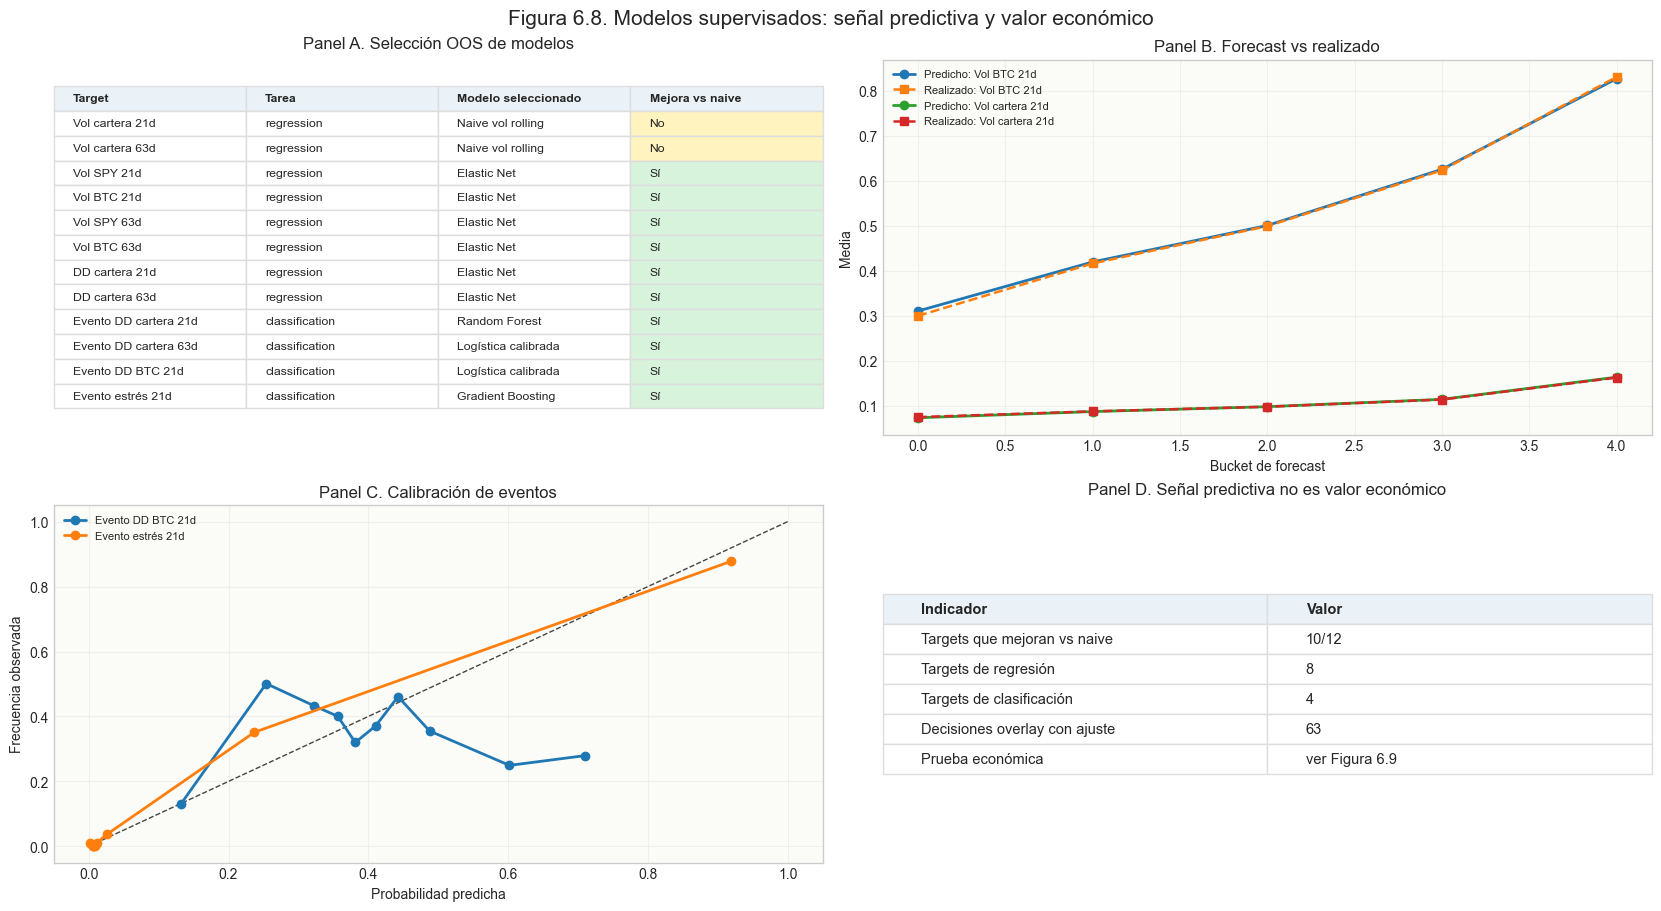

**Qué muestra:** Selección de modelos, buckets de forecast, calibración de eventos y resumen de uso económico.  \n**Qué se observa:** Hay señal OOS en varios targets (10/12 mejoran al naive), pero esa señal debe juzgarse por su efecto en la cartera.  \n**Qué implica:** Que un modelo prediga algo no significa que mejore la cartera. La prueba real es económica: drawdown, ES95, Calmar, costes y deltas frente a MinVar.  \n**Limitación:** La figura usa outputs agregados; no muestra predicciones fila a fila ni prueba causal individual de cada intervención.

In [429]:
def vis_target_label(name: str) -> str:
    mapping = {
        "target_portfolio_vol_21d": "Vol cartera 21d",
        "target_portfolio_vol_63d": "Vol cartera 63d",
        "target_spy_vol_21d": "Vol SPY 21d",
        "target_spy_vol_63d": "Vol SPY 63d",
        "target_btc_vol_21d": "Vol BTC 21d",
        "target_btc_vol_63d": "Vol BTC 63d",
        "target_portfolio_dd_21d": "DD cartera 21d",
        "target_portfolio_dd_63d": "DD cartera 63d",
        "target_portfolio_dd_event_21d": "Evento DD cartera 21d",
        "target_portfolio_dd_event_63d": "Evento DD cartera 63d",
        "target_btc_dd_event_21d": "Evento DD BTC 21d",
        "target_stress_event_21d": "Evento estrés 21d",
    }
    return mapping.get(name, name)


def vis_model_label(name: str) -> str:
    mapping = {
        "naive_rolling_vol": "Naive vol rolling",
        "ewma": "EWMA",
        "ridge": "Ridge",
        "elastic_net": "Elastic Net",
        "random_forest": "Random Forest",
        "random_forest_classifier": "Random Forest",
        "gradient_boosting_classifier": "Gradient Boosting",
        "logistic": "Logística",
        "calibrated_logistic": "Logística calibrada",
    }
    return mapping.get(name, name)

if VIS_MODEL_SCORES is None or VIS_MODEL_SCORES.empty or VIS_MODEL_SELECTION is None or VIS_MODEL_SELECTION.empty:
    vis_note("No están disponibles `model_scores.csv` o `model_selection.csv`.")
    vis_show_reading(
        "La selección de modelos, buckets de forecast y calibración de eventos.",
        "La figura no puede renderizarse porque faltan scores o selección de modelos.",
        "Sin scores fuera de muestra no conviene sobrerreivindicar valor predictivo.",
        "Los paneles de buckets y calibración requieren outputs agregados de Chapter 5.",
    )
else:
    selection = VIS_MODEL_SELECTION.copy()
    selection["Target"] = selection["target_col"].map(vis_target_label)
    selection["Modelo seleccionado"] = selection["selected_model"].map(vis_model_label)
    selection["Mejora vs naive"] = selection["improved_vs_naive"].map({True: "Sí", False: "No"})
    selection_view = selection[["Target", "task", "Modelo seleccionado", "Mejora vs naive"]].rename(columns={"task": "Tarea"}).head(12)

    fig = plt.figure(figsize=(16.5, 9.0), constrained_layout=True)
    grid = fig.add_gridspec(2, 2, height_ratios=[1.05, 1.0])
    ax_sel = fig.add_subplot(grid[0, 0])
    ax_bucket = fig.add_subplot(grid[0, 1])
    ax_cal = fig.add_subplot(grid[1, 0])
    ax_summary = fig.add_subplot(grid[1, 1])

    ax_sel.axis("off")
    table = ax_sel.table(cellText=selection_view.values, colLabels=selection_view.columns, cellLoc="left", colLoc="left", loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(8.8)
    table.scale(1.0, 1.28)
    for row_idx in range(len(selection_view) + 1):
        for col_idx in range(len(selection_view.columns)):
            cell = table[row_idx, col_idx]
            cell.set_edgecolor("#dddddd")
            if row_idx == 0:
                cell.set_facecolor("#eaf2f8")
                cell.set_text_props(weight="bold")
            elif col_idx == 3:
                cell.set_facecolor("#d8f3dc" if selection_view.iloc[row_idx - 1, col_idx] == "Sí" else "#fff3bf")
    ax_sel.set_title("Panel A. Selección OOS de modelos", fontsize=12, pad=8)

    forecast = pd.DataFrame()
    if VIS_FORECAST_BUCKETS is not None and not VIS_FORECAST_BUCKETS.empty:
        selected_reg = VIS_MODEL_SELECTION.loc[VIS_MODEL_SELECTION["task"] == "regression", ["target_col", "selected_model"]]
        forecast = VIS_FORECAST_BUCKETS.merge(selected_reg, left_on=["target_col", "model_name"], right_on=["target_col", "selected_model"], how="inner")
        chosen_targets = [target for target in ["target_portfolio_vol_21d", "target_btc_vol_21d"] if target in forecast["target_col"].unique()]
        forecast = forecast.loc[forecast["target_col"].isin(chosen_targets)].copy()

    if forecast.empty:
        ax_bucket.text(0.5, 0.5, "Sin análisis por buckets", ha="center", va="center", fontsize=11)
        ax_bucket.axis("off")
    else:
        for target in forecast["target_col"].unique():
            sub = forecast.loc[forecast["target_col"] == target].sort_values("bucket")
            label = vis_target_label(target)
            ax_bucket.plot(sub["bucket"], sub["mean_pred"], marker="o", linewidth=2.0, label=f"Predicho: {label}")
            ax_bucket.plot(sub["bucket"], sub["mean_realized"], marker="s", linewidth=1.8, linestyle="--", label=f"Realizado: {label}")
        ax_bucket.set_title("Panel B. Forecast vs realizado", fontsize=12)
        ax_bucket.set_xlabel("Bucket de forecast")
        ax_bucket.set_ylabel("Media")
        ax_bucket.grid(True, alpha=0.25)
        ax_bucket.legend(frameon=False, fontsize=8)

    calibration = pd.DataFrame()
    if VIS_CALIBRATION is not None and not VIS_CALIBRATION.empty:
        selected_cls = VIS_MODEL_SELECTION.loc[VIS_MODEL_SELECTION["task"] == "classification", ["target_col", "selected_model"]]
        calibration = VIS_CALIBRATION.merge(selected_cls, left_on=["target_col", "model_name"], right_on=["target_col", "selected_model"], how="inner")
        chosen_targets = [target for target in ["target_stress_event_21d", "target_btc_dd_event_21d"] if target in calibration["target_col"].unique()]
        calibration = calibration.loc[calibration["target_col"].isin(chosen_targets)].copy()

    if calibration.empty:
        ax_cal.text(0.5, 0.5, "Sin calibración agregada", ha="center", va="center", fontsize=11)
        ax_cal.axis("off")
    else:
        ax_cal.plot([0, 1], [0, 1], color="#444444", linestyle="--", linewidth=1.0)
        for target in calibration["target_col"].unique():
            sub = calibration.loc[calibration["target_col"] == target].sort_values("decile")
            ax_cal.plot(sub["mean_score"], sub["event_rate"], marker="o", linewidth=2.0, label=vis_target_label(target))
        ax_cal.set_title("Panel C. Calibración de eventos", fontsize=12)
        ax_cal.set_xlabel("Probabilidad predicha")
        ax_cal.set_ylabel("Frecuencia observada")
        ax_cal.grid(True, alpha=0.25)
        ax_cal.legend(frameon=False, fontsize=8)

    improved = int(VIS_MODEL_SELECTION["improved_vs_naive"].fillna(False).sum())
    total = int(len(VIS_MODEL_SELECTION))
    overlay_uses = 0
    if VIS_OVERLAY_DECISIONS is not None and not VIS_OVERLAY_DECISIONS.empty:
        overlay_uses = int((VIS_OVERLAY_DECISIONS["reason"].fillna("none") != "none").sum())
    summary_df = pd.DataFrame([
        ["Targets que mejoran vs naive", f"{improved}/{total}"],
        ["Targets de regresión", int((VIS_MODEL_SELECTION["task"] == "regression").sum())],
        ["Targets de clasificación", int((VIS_MODEL_SELECTION["task"] == "classification").sum())],
        ["Decisiones overlay con ajuste", overlay_uses],
        ["Prueba económica", "ver Figura 6.9"],
    ], columns=["Indicador", "Valor"])
    ax_summary.axis("off")
    table = ax_summary.table(cellText=summary_df.values, colLabels=summary_df.columns, cellLoc="left", colLoc="left", loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(10.5)
    table.scale(1.0, 1.55)
    for row_idx in range(len(summary_df) + 1):
        for col_idx in range(len(summary_df.columns)):
            cell = table[row_idx, col_idx]
            cell.set_edgecolor("#dddddd")
            if row_idx == 0:
                cell.set_facecolor("#eaf2f8")
                cell.set_text_props(weight="bold")
    ax_summary.set_title("Panel D. Señal predictiva no es valor económico", fontsize=12, pad=8)

    fig.suptitle("Figura 6.8. Modelos supervisados: señal predictiva y valor económico", fontsize=15)
    plt.show()

    vis_show_reading(
        "Selección de modelos, buckets de forecast, calibración de eventos y resumen de uso económico.",
        f"Hay señal OOS en varios targets ({improved}/{total} mejoran al naive), pero esa señal debe juzgarse por su efecto en la cartera.",
        "Que un modelo prediga algo no significa que mejore la cartera. La prueba real es económica: drawdown, ES95, Calmar, costes y deltas frente a MinVar.",
        "La figura usa outputs agregados; no muestra predicciones fila a fila ni prueba causal individual de cada intervención.",
    )

### Figura 6.9 — Overlay: decisiones y valor económico

**Pregunta de investigación.** ¿El overlay actúa de forma trazable y mejora el perfil económico neto frente a MinVar?

**Cómo se implementó**
- Código principal: `src/risk_overlay.py`, `src/overlay_backtest.py`
- Script: `scripts/run_risk_overlay.py`, `scripts/run_chapter5.py`
- Outputs usados: `outputs/chapter5/overlay_backtest_summary.csv`, `outputs/chapter5/overlay_decisions.csv`, `outputs/chapter5/overlay_weights.csv`
- Qué contrasta: motivos de activación, recorte aplicado al peso crypto y deltas de métricas frente a MinVar.
- Qué permite concluir: si la capa supervisada aporta valor económico o solo trazabilidad prudencial.

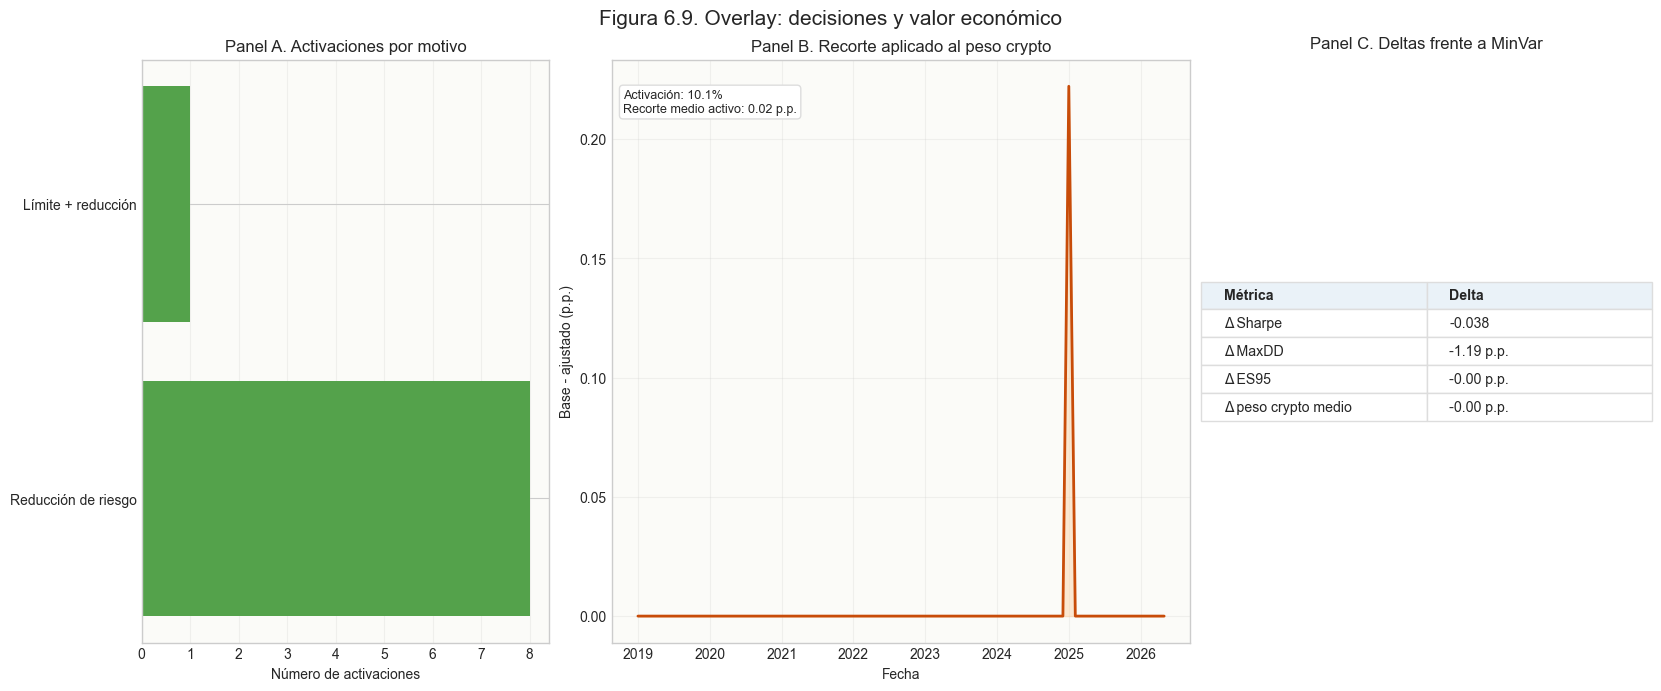

**Qué muestra:** Motivos de activación, recorte aplicado al peso crypto y deltas económicos frente a MinVar.  \n**Qué se observa:** El overlay combinado se activa en 10.1% de observaciones relevantes; cuando actúa, recorta crypto, pero el impacto neto agregado sigue siendo limitado.  \n**Qué implica:** El overlay puede ser trazable, pero si no mejora métricas de riesgo netas, su valor económico es limitado.  \n**Limitación:** La figura no atribuye causalmente cada mejora o deterioro a una intervención individual; resume el efecto agregado del overlay.

In [430]:
overlay_target = "minvar_combined_overlay"
if VIS_OVERLAY_DECISIONS is None or VIS_OVERLAY_DECISIONS.empty or VIS_OVERLAY_SUMMARY is None or VIS_OVERLAY_SUMMARY.empty:
    vis_note("Faltan `overlay_decisions.csv` o `overlay_backtest_summary.csv`.")
    vis_show_reading(
        "Los disparadores del overlay, el recorte aplicado y su impacto económico frente a MinVar.",
        "La figura no puede renderizarse completa porque faltan outputs del capítulo 5.",
        "Sin decisiones registradas y sin resumen económico no puede juzgarse el valor del overlay.",
        "La capa supervisada solo se evalúa aquí con outputs finales, no con entrenamiento ni predicciones crudas.",
    )
else:
    decisions = VIS_OVERLAY_DECISIONS.copy()
    decisions["date"] = pd.to_datetime(decisions["date"])
    if overlay_target not in decisions["strategy"].unique():
        candidates = decisions.loc[~decisions["strategy"].isin(["minvar_baseline_corrected", "minvar_no_crypto_control"]), "strategy"]
        overlay_target = candidates.iloc[0] if not candidates.empty else decisions["strategy"].iloc[0]
    overlay_name = vis_h_strategy(overlay_target)
    overlay_path = decisions.loc[decisions["strategy"] == overlay_target].sort_values("date").copy()
    overlay_path["cut"] = (overlay_path["base_crypto_weight"] - overlay_path["adjusted_crypto_weight"]).clip(lower=0)
    activation_mask = (overlay_path["reason"].fillna("none") != "none") | overlay_path["cut"].gt(1e-8)
    activation_rate = float(activation_mask.mean()) if len(overlay_path) else np.nan
    mean_cut_active = overlay_path.loc[activation_mask, "cut"].mean() if activation_mask.any() else 0.0

    reason_map = {
        "dynamic_crypto_cap": "Límite crypto",
        "de_risking": "Reducción de riesgo",
        "dynamic_crypto_cap|de_risking": "Límite + reducción",
        "none": "Sin ajuste",
    }
    reason_counts = overlay_path.loc[activation_mask].copy()
    reason_counts["Motivo"] = reason_counts["reason"].fillna("none").map(lambda x: reason_map.get(x, x.replace("_", " ")))
    reason_counts = reason_counts.groupby("Motivo", as_index=False).size().sort_values("size", ascending=False)

    baseline_row = vis_pick_row(VIS_OVERLAY_SUMMARY, "strategy", "minvar_baseline_corrected")
    overlay_row = vis_pick_row(VIS_OVERLAY_SUMMARY, "strategy", overlay_target)

    fig = plt.figure(figsize=(16.5, 6.8), constrained_layout=True)
    grid = fig.add_gridspec(1, 3, width_ratios=[0.95, 1.35, 1.05])
    ax_reason = fig.add_subplot(grid[0, 0])
    ax_cut = fig.add_subplot(grid[0, 1])
    ax_delta = fig.add_subplot(grid[0, 2])

    if reason_counts.empty:
        ax_reason.text(0.5, 0.5, "Sin activaciones relevantes", ha="center", va="center", fontsize=11)
        ax_reason.axis("off")
    else:
        ax_reason.barh(reason_counts["Motivo"], reason_counts["size"], color="#54a24b")
        ax_reason.set_title("Panel A. Activaciones por motivo", fontsize=12)
        ax_reason.set_xlabel("Número de activaciones")
        ax_reason.grid(True, axis="x", alpha=0.25)

    ax_cut.plot(overlay_path["date"], overlay_path["cut"] * 100.0, linewidth=2.0, color="#c84c09")
    ax_cut.fill_between(overlay_path["date"], 0, overlay_path["cut"] * 100.0, color="#fdd0a2", alpha=0.45)
    ax_cut.set_title("Panel B. Recorte aplicado al peso crypto", fontsize=12)
    ax_cut.set_xlabel("Fecha")
    ax_cut.set_ylabel("Base - ajustado (p.p.)")
    ax_cut.grid(True, alpha=0.25)
    ax_cut.text(0.02, 0.95, f"Activación: {activation_rate * 100:.1f}%\nRecorte medio activo: {mean_cut_active * 100:.2f} p.p.", transform=ax_cut.transAxes, ha="left", va="top", fontsize=9, bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": "#dddddd"})

    ax_delta.axis("off")
    if baseline_row.empty or overlay_row.empty:
        ax_delta.text(0.5, 0.5, "Sin delta económico", ha="center", va="center", fontsize=11)
    else:
        delta_table = pd.DataFrame({
            "Métrica": ["Δ Sharpe", "Δ MaxDD", "Δ ES95", "Δ peso crypto medio"],
            "Delta": [
                f"{vis_metric(overlay_row, 'sharpe') - vis_metric(baseline_row, 'sharpe'):+.3f}",
                f"{(vis_metric(overlay_row, 'max_drawdown') - vis_metric(baseline_row, 'max_drawdown')) * 100.0:+.2f} p.p.",
                f"{(vis_metric(overlay_row, 'es95') - vis_metric(baseline_row, 'es95')) * 100.0:+.2f} p.p.",
                f"{(vis_metric(overlay_row, 'avg_crypto_weight', 'crypto_avg_weight') - vis_metric(baseline_row, 'avg_crypto_weight', 'crypto_avg_weight')) * 100.0:+.2f} p.p.",
            ],
        })
        table = ax_delta.table(cellText=delta_table.values, colLabels=delta_table.columns, cellLoc="left", colLoc="left", loc="center")
        table.auto_set_font_size(False)
        table.set_fontsize(10.2)
        table.scale(1.0, 1.5)
        for row_idx in range(len(delta_table) + 1):
            for col_idx in range(len(delta_table.columns)):
                cell = table[row_idx, col_idx]
                cell.set_edgecolor("#dddddd")
                if row_idx == 0:
                    cell.set_facecolor("#eaf2f8")
                    cell.set_text_props(weight="bold")
    ax_delta.set_title("Panel C. Deltas frente a MinVar", fontsize=12, pad=8)

    fig.suptitle("Figura 6.9. Overlay: decisiones y valor económico", fontsize=15)
    plt.show()

    vis_show_reading(
        "Motivos de activación, recorte aplicado al peso crypto y deltas económicos frente a MinVar.",
        f"El {overlay_name.lower()} se activa en {activation_rate * 100:.1f}% de observaciones relevantes; cuando actúa, recorta crypto, pero el impacto neto agregado sigue siendo limitado.",
        "El overlay puede ser trazable, pero si no mejora métricas de riesgo netas, su valor económico es limitado.",
        "La figura no atribuye causalmente cada mejora o deterioro a una intervención individual; resume el efecto agregado del overlay.",
    )

### Nota metodológica secundaria — Trazabilidad de la auditoría

La comparación before/after se conserva solo como trazabilidad breve. El bloque visual principal usa exclusivamente la metodología final del proyecto.

In [431]:
if VIS_AUDIT is None or VIS_AUDIT.empty:
    vis_note("No está disponible `audit_fix_comparison.csv`; se omite la tabla secundaria de trazabilidad metodológica.")
else:
    before = VIS_AUDIT.loc[VIS_AUDIT["scenario"].str.contains("before", case=False, na=False)].head(1)
    after = VIS_AUDIT.loc[VIS_AUDIT["scenario"].str.contains("after", case=False, na=False)].head(1)

    if before.empty or after.empty:
        vis_note("El CSV de auditoría existe, pero no identifica con claridad los escenarios before/after.")
    else:
        trace = pd.DataFrame([
            {"Métrica": "Filas de fin de semana", "Antes": int(before.iloc[0]["n_weekend_rows"]), "Final": int(after.iloc[0]["n_weekend_rows"])},
            {"Métrica": "Sharpe", "Antes": f"{float(before.iloc[0]['sharpe']):.3f}", "Final": f"{float(after.iloc[0]['sharpe']):.3f}"},
            {"Métrica": "ES95", "Antes": f"{float(before.iloc[0]['es95']) * 100.0:.2f}%", "Final": f"{float(after.iloc[0]['es95']) * 100.0:.2f}%"},
            {"Métrica": "Peso crypto medio", "Antes": f"{float(before.iloc[0]['average_crypto_weight']) * 100.0:.2f}%", "Final": f"{float(after.iloc[0]['average_crypto_weight']) * 100.0:.2f}%"},
            {"Métrica": "Rebalanceos con crypto > 2%", "Antes": int(before.iloc[0]['rebalances_crypto_gt_2pct']), "Final": int(after.iloc[0]['rebalances_crypto_gt_2pct'])},
        ])
        vis_note("Esta tabla se mantiene solo como trazabilidad metodológica. Todas las figuras principales usan el baseline final.")
        display(trace.style.hide(axis="index"))

> **Nota:** Esta tabla se mantiene solo como trazabilidad metodológica. Todas las figuras principales usan el baseline final.

Métrica,Antes,Final
Filas de fin de semana,869,0
Sharpe,1.141,1.096
ES95,1.34%,1.55%
Peso crypto medio,0.76%,0.53%
Rebalanceos con crypto > 2%,14,6


### Figura 6.10 — Dashboard final de evidencia

**Pregunta de investigación.** ¿Qué afirmaciones quedan defendibles después de separar construcción MinVar, efecto crypto, CVaR, regímenes y overlay?

**Cómo se implementó**
- Código principal: síntesis de outputs finales de capítulos 1 a 5.
- Script: no ejecuta scripts; consume artefactos generados por los scripts de capítulos.
- Outputs usados: `data/processed/backtest_summary.csv`, `data/processed/benchmark_summary.csv`, `data/processed/robustness/confidence_summary.csv`, `data/processed/tail_risk/tail_risk_summary_net.csv`, `data/processed/regime_analysis/regime_conditional_performance_net.csv`, `outputs/chapter5/overlay_backtest_summary.csv`
- Qué contrasta: hipótesis principales, evidencia, veredicto y confianza.
- Qué permite concluir: el cierre de la tesis empírica sin afirmaciones absolutas.

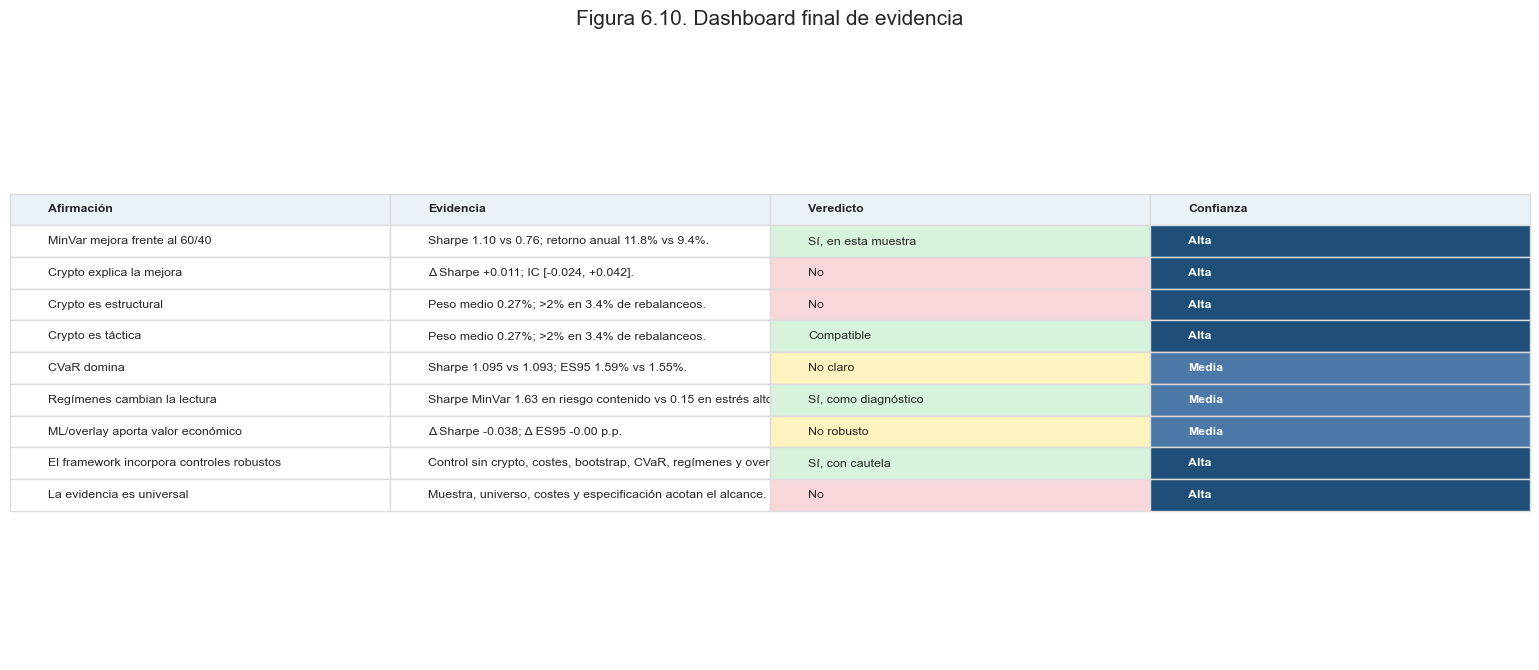

**Qué muestra:** Una matriz final de afirmaciones con evidencia, veredicto y confianza.  \n**Qué se observa:** La evidencia respalda MinVar frente al 60/40 y una lectura táctica de crypto; no respalda que BTC/ETH expliquen robustamente la mejora ni que CVaR u overlay cambien la tesis.  \n**Qué implica:** La evidencia principal es metodológicamente defendible, no universal: está acotada por muestra, universo, costes y especificación.  \n**Limitación:** El dashboard sintetiza juicio económico sobre outputs previos; no reemplaza la lectura de las figuras y tablas que lo sustentan.

In [432]:
rows = []

bench_6040 = vis_pick_row(VIS_BENCH, "benchmark", "sixty_forty")
backtest_minvar = vis_pick_row(VIS_BACKTEST, "strategy", "min_variance")
if not bench_6040.empty and not backtest_minvar.empty:
    evidence = (
        f"Sharpe {vis_metric(backtest_minvar, 'sharpe'):.2f} vs {vis_metric(bench_6040, 'sharpe'):.2f}; "
        f"retorno anual {vis_metric(backtest_minvar, 'ann_return') * 100.0:.1f}% vs {vis_metric(bench_6040, 'ann_return') * 100.0:.1f}%."
    )
else:
    evidence = "Comparación MinVar/60-40 no disponible."
rows.append({"Afirmación": "MinVar mejora frente al 60/40", "Evidencia": evidence, "Veredicto": "Sí, en esta muestra", "Confianza": "Alta"})

crypto_evidence = "Control sin crypto no disponible."
crypto_conf = "Media"
if not VIS_BASELINE_ROW.empty and not VIS_NO_CRYPTO_ROW.empty:
    delta_sharpe = vis_metric(VIS_BASELINE_ROW, "sharpe") - vis_metric(VIS_NO_CRYPTO_ROW, "sharpe")
    crypto_evidence = f"Δ Sharpe {delta_sharpe:+.3f}."
    if VIS_CONFIDENCE is not None and not VIS_CONFIDENCE.empty:
        anchor = VIS_CONFIDENCE.loc[VIS_CONFIDENCE["comparison_id"] == "C1_anchor_pair"]
        if not anchor.empty:
            crypto_evidence = f"Δ Sharpe {delta_sharpe:+.3f}; IC [{float(anchor.iloc[0]['ci_lower']):+.3f}, {float(anchor.iloc[0]['ci_upper']):+.3f}]."
            crypto_conf = "Alta" if bool(anchor.iloc[0]["ci_includes_zero"]) else "Media"
rows.append({"Afirmación": "Crypto explica la mejora", "Evidencia": crypto_evidence, "Veredicto": "No", "Confianza": crypto_conf})

crypto_weight_evidence = "Sin panel consolidado de pesos."
if not VIS_CRYPTO_PANEL.empty:
    focus = VIS_CRYPTO_PANEL.loc[VIS_CRYPTO_PANEL["Estrategia"] == "MinVar", "crypto_total"]
    if not focus.empty:
        crypto_weight_evidence = f"Peso medio {focus.mean() * 100.0:.2f}%; >2% en {(focus > 0.02).mean() * 100.0:.1f}% de rebalanceos."
rows.append({"Afirmación": "Crypto es estructural", "Evidencia": crypto_weight_evidence, "Veredicto": "No", "Confianza": "Alta"})
rows.append({"Afirmación": "Crypto es táctica", "Evidencia": crypto_weight_evidence, "Veredicto": "Compatible", "Confianza": "Alta"})

cvar_evidence = "Comparación CVaR-MinVar no disponible."
if VIS_TAIL_NET is not None and not VIS_TAIL_NET.empty:
    cvar_row = vis_pick_row(VIS_TAIL_NET, "strategy", "cvar_baseline")
    minvar_row = vis_pick_row(VIS_TAIL_NET, "strategy", "minvar_baseline_ch1")
    if not cvar_row.empty and not minvar_row.empty:
        cvar_evidence = (
            f"Sharpe {vis_metric(cvar_row, 'sharpe_net'):.3f} vs {vis_metric(minvar_row, 'sharpe_net'):.3f}; "
            f"ES95 {vis_metric(cvar_row, 'expected_shortfall_net') * 100.0:.2f}% vs {vis_metric(minvar_row, 'expected_shortfall_net') * 100.0:.2f}%."
        )
rows.append({"Afirmación": "CVaR domina", "Evidencia": cvar_evidence, "Veredicto": "No claro", "Confianza": "Media"})

regime_evidence = "Performance por régimen no disponible."
if VIS_REGIME_PERF is not None and not VIS_REGIME_PERF.empty:
    mv_reg = VIS_REGIME_PERF.loc[VIS_REGIME_PERF["strategy"] == "minvar_baseline_ch1"]
    low = mv_reg.loc[mv_reg["regime_name"] == "Low-stress / Risk-on", "sharpe"]
    high = mv_reg.loc[mv_reg["regime_name"] == "High-stress / Risk-off", "sharpe"]
    if not low.empty and not high.empty:
        regime_evidence = f"Sharpe MinVar {float(low.iloc[0]):.2f} en riesgo contenido vs {float(high.iloc[0]):.2f} en estrés alto."
rows.append({"Afirmación": "Regímenes cambian la lectura", "Evidencia": regime_evidence, "Veredicto": "Sí, como diagnóstico", "Confianza": "Media"})

overlay_evidence = "Comparación overlay-MinVar no disponible."
if not VIS_BASELINE_ROW.empty and not VIS_OVERLAY_ROW.empty:
    delta_sharpe_overlay = vis_metric(VIS_OVERLAY_ROW, "sharpe") - vis_metric(VIS_BASELINE_ROW, "sharpe")
    delta_es_overlay = vis_metric(VIS_OVERLAY_ROW, "es95") - vis_metric(VIS_BASELINE_ROW, "es95")
    overlay_evidence = f"Δ Sharpe {delta_sharpe_overlay:+.3f}; Δ ES95 {delta_es_overlay * 100.0:+.2f} p.p."
rows.append({"Afirmación": "ML/overlay aporta valor económico", "Evidencia": overlay_evidence, "Veredicto": "No robusto", "Confianza": "Media"})

rows.append({
    "Afirmación": "El framework incorpora controles robustos",
    "Evidencia": "Control sin crypto, costes, bootstrap, CVaR, regímenes y overlay.",
    "Veredicto": "Sí, con cautela",
    "Confianza": "Alta",
})
rows.append({
    "Afirmación": "La evidencia es universal",
    "Evidencia": "Muestra, universo, costes y especificación acotan el alcance.",
    "Veredicto": "No",
    "Confianza": "Alta",
})

dashboard = pd.DataFrame(rows)
verdict_colors = {"Sí, en esta muestra": "#d8f3dc", "Sí, con cautela": "#d8f3dc", "Sí, como diagnóstico": "#d8f3dc", "No": "#f8d7da", "No claro": "#fff3bf", "No robusto": "#fff3bf", "Compatible": "#d8f3dc"}
confidence_colors = {"Alta": "#1f4e79", "Media": "#4c78a8", "Baja": "#9ecae1"}

fig, ax = plt.subplots(figsize=(15.5, 6.8))
ax.axis("off")
table = ax.table(cellText=dashboard.values, colLabels=dashboard.columns, cellLoc="left", colLoc="left", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(8.9)
table.scale(1, 1.62)

for row_idx in range(len(dashboard) + 1):
    for col_idx in range(len(dashboard.columns)):
        cell = table[row_idx, col_idx]
        cell.set_edgecolor("#dddddd")
        if row_idx == 0:
            cell.set_facecolor("#eaf2f8")
            cell.set_text_props(weight="bold")
        else:
            if col_idx == 2:
                cell.set_facecolor(verdict_colors.get(dashboard.iloc[row_idx - 1, col_idx], "white"))
            elif col_idx == 3:
                color = confidence_colors.get(dashboard.iloc[row_idx - 1, col_idx], "#ffffff")
                cell.set_facecolor(color)
                cell.set_text_props(color="white" if color in ["#1f4e79", "#4c78a8"] else "black", weight="bold")

ax.set_title("Figura 6.10. Dashboard final de evidencia", fontsize=15, pad=14)
plt.tight_layout()
plt.show()

vis_show_reading(
    "Una matriz final de afirmaciones con evidencia, veredicto y confianza.",
    "La evidencia respalda MinVar frente al 60/40 y una lectura táctica de crypto; no respalda que BTC/ETH expliquen robustamente la mejora ni que CVaR u overlay cambien la tesis.",
    "La evidencia principal es metodológicamente defendible, no universal: está acotada por muestra, universo, costes y especificación.",
    "El dashboard sintetiza juicio económico sobre outputs previos; no reemplaza la lectura de las figuras y tablas que lo sustentan.",
)

## 12. Limitaciones

Las conclusiones deben leerse como evidencia aplicada bajo una especificación concreta, no como resultado universal. Esta sección explicita los puntos débiles que condicionan la interpretación.

In [433]:
limitations_text = """
- **Muestra y periodo.** La ventana OOS cubre un periodo relevante, pero sigue siendo limitada para activos con ciclos extremos como BTC y ETH.
- **Universo de activos.** El resultado depende del conjunto de activos incluido; otros universos podrían cambiar correlaciones, restricciones y oportunidades de diversificación.
- **Costes y liquidez.** El modelo incorpora costes explícitos, pero no modela toda la microestructura, slippage variable, impacto de mercado o restricciones de capacidad.
- **Estimación de riesgo.** MinVar, CVaR y regímenes dependen de ventanas, covarianzas, definición de cola y estabilidad de parámetros.
- **Bootstrap.** Los intervalos por bloques capturan parte de la dependencia temporal, pero no eliminan riesgo de especificación ni de múltiples comparaciones.
- **Regímenes.** Los estados de mercado son diagnósticos históricos. No se validan aquí como señal live de asignación.
- **Modelos supervisados.** Una mejora predictiva en targets de riesgo no garantiza valor económico neto. El overlay debe evaluarse por métricas finales de cartera.
- **Alcance de la conclusión crypto.** La evidencia rechaza una asignación estructural bajo este framework; no prueba que BTC/ETH nunca puedan tener valor táctico bajo otras reglas.
"""

display(Markdown(limitations_text))


- **Muestra y periodo.** La ventana OOS cubre un periodo relevante, pero sigue siendo limitada para activos con ciclos extremos como BTC y ETH.
- **Universo de activos.** El resultado depende del conjunto de activos incluido; otros universos podrían cambiar correlaciones, restricciones y oportunidades de diversificación.
- **Costes y liquidez.** El modelo incorpora costes explícitos, pero no modela toda la microestructura, slippage variable, impacto de mercado o restricciones de capacidad.
- **Estimación de riesgo.** MinVar, CVaR y regímenes dependen de ventanas, covarianzas, definición de cola y estabilidad de parámetros.
- **Bootstrap.** Los intervalos por bloques capturan parte de la dependencia temporal, pero no eliminan riesgo de especificación ni de múltiples comparaciones.
- **Regímenes.** Los estados de mercado son diagnósticos históricos. No se validan aquí como señal live de asignación.
- **Modelos supervisados.** Una mejora predictiva en targets de riesgo no garantiza valor económico neto. El overlay debe evaluarse por métricas finales de cartera.
- **Alcance de la conclusión crypto.** La evidencia rechaza una asignación estructural bajo este framework; no prueba que BTC/ETH nunca puedan tener valor táctico bajo otras reglas.


## 13. Conclusión final

La conclusión distingue explícitamente cinco capas: construcción MinVar, permiso a crypto, objetivo de cola, diagnóstico por regímenes y overlay supervisado.

In [434]:
conclusion_text = """
La evidencia favorece una conclusión positiva para la construcción risk-based y negativa para la tesis estructural de crypto. En la ventana evaluada, MinVar mejora el perfil retorno-riesgo frente al 60/40 tradicional. Sin embargo, esa mejora no se explica limpiamente por BTC/ETH: el control sin crypto queda muy cerca, el delta de Sharpe atribuible a crypto es pequeño y el intervalo bootstrap cruza cero.

La exposición efectiva refuerza esta lectura. Una asignación estructural debería aparecer con frecuencia y tamaño económico material. En cambio, BTC/ETH aparecen con pesos bajos, mediana cercana a cero y episodios escasos por encima de 2%.

CVaR, regímenes y modelos supervisados aportan pruebas adicionales, no una reversión de la tesis. CVaR permite mirar riesgo de cola, pero no domina claramente a MinVar. Los regímenes muestran que el rendimiento depende del estado de mercado, pero funcionan como diagnóstico histórico, no como regla predictiva validada. Los modelos supervisados capturan señal en varios targets de riesgo, aunque esa señal no se traduce de forma robusta en valor económico neto del overlay.

Bajo este framework OOS, con costes, control sin crypto, bootstrap, CVaR, regímenes y overlay, BTC/ETH no justifican una asignación estructural. Su papel defendible es, como máximo, táctico, de baja intensidad y dependiente del contexto.
"""

display(Markdown(conclusion_text))


La evidencia favorece una conclusión positiva para la construcción risk-based y negativa para la tesis estructural de crypto. En la ventana evaluada, MinVar mejora el perfil retorno-riesgo frente al 60/40 tradicional. Sin embargo, esa mejora no se explica limpiamente por BTC/ETH: el control sin crypto queda muy cerca, el delta de Sharpe atribuible a crypto es pequeño y el intervalo bootstrap cruza cero.

La exposición efectiva refuerza esta lectura. Una asignación estructural debería aparecer con frecuencia y tamaño económico material. En cambio, BTC/ETH aparecen con pesos bajos, mediana cercana a cero y episodios escasos por encima de 2%.

CVaR, regímenes y modelos supervisados aportan pruebas adicionales, no una reversión de la tesis. CVaR permite mirar riesgo de cola, pero no domina claramente a MinVar. Los regímenes muestran que el rendimiento depende del estado de mercado, pero funcionan como diagnóstico histórico, no como regla predictiva validada. Los modelos supervisados capturan señal en varios targets de riesgo, aunque esa señal no se traduce de forma robusta en valor económico neto del overlay.

Bajo este framework OOS, con costes, control sin crypto, bootstrap, CVaR, regímenes y overlay, BTC/ETH no justifican una asignación estructural. Su papel defendible es, como máximo, táctico, de baja intensidad y dependiente del contexto.


## 14. Resumen para publicación académica/divulgativa

Esta versión resume la contribución del estudio en una página: pregunta, método, evidencia principal, cautelas y conclusión.

In [435]:
publication_summary = """
**Crypto-Enhanced Multi-Asset Portfolio Optimization: A Quantitative Risk-Based Approach** evalúa si BTC y ETH aportan beneficios robustos de diversificación dentro de una cartera multi-activo optimizada por riesgo.

El diseño empírico compara MinVar contra el 60/40 tradicional, añade un control sin crypto, incorpora costes y valida la incertidumbre con bootstrap. Después somete la tesis crypto a tres pruebas adicionales: optimización CVaR, regímenes de mercado y overlay supervisado de riesgo.

El resultado principal es claro: MinVar mejora el perfil de la cartera frente al 60/40, pero el permiso a BTC/ETH no explica robustamente esa mejora. La diferencia incremental frente al control sin crypto es pequeña, el intervalo bootstrap cruza cero y la exposición media a crypto es baja e intermitente.

La optimización de cola, los regímenes y el overlay supervisado no cambian materialmente la conclusión. CVaR no domina de forma clara a MinVar; los regímenes contextualizan el riesgo, pero no validan una regla live; y la señal predictiva de los modelos no se convierte de forma robusta en mejora económica neta.

La contribución del proyecto es separar tres ideas que suelen mezclarse: que MinVar puede aportar valor, que crypto puede aparecer tácticamente, y que eso no equivale a justificar una asignación estructural a BTC/ETH.
"""

display(Markdown(publication_summary))


**Crypto-Enhanced Multi-Asset Portfolio Optimization: A Quantitative Risk-Based Approach** evalúa si BTC y ETH aportan beneficios robustos de diversificación dentro de una cartera multi-activo optimizada por riesgo.

El diseño empírico compara MinVar contra el 60/40 tradicional, añade un control sin crypto, incorpora costes y valida la incertidumbre con bootstrap. Después somete la tesis crypto a tres pruebas adicionales: optimización CVaR, regímenes de mercado y overlay supervisado de riesgo.

El resultado principal es claro: MinVar mejora el perfil de la cartera frente al 60/40, pero el permiso a BTC/ETH no explica robustamente esa mejora. La diferencia incremental frente al control sin crypto es pequeña, el intervalo bootstrap cruza cero y la exposición media a crypto es baja e intermitente.

La optimización de cola, los regímenes y el overlay supervisado no cambian materialmente la conclusión. CVaR no domina de forma clara a MinVar; los regímenes contextualizan el riesgo, pero no validan una regla live; y la señal predictiva de los modelos no se convierte de forma robusta en mejora económica neta.

La contribución del proyecto es separar tres ideas que suelen mezclarse: que MinVar puede aportar valor, que crypto puede aparecer tácticamente, y que eso no equivale a justificar una asignación estructural a BTC/ETH.


## 15. Referencias

Lista breve de referencias metodológicas y artefactos internos usados para situar la nota.

In [ ]:
references_text = """
**Referencias metodológicas**

- Markowitz, H. (1952). Portfolio Selection. *Journal of Finance*.
- Rockafellar, R. T. and Uryasev, S. (2000). Optimization of Conditional Value-at-Risk. *Journal of Risk*.
- Ledoit, O. and Wolf, M. (2004). A well-conditioned estimator for large-dimensional covariance matrices. *Journal of Multivariate Analysis*.
- DeMiguel, V., Garlappi, L. and Uppal, R. (2009). Optimal versus naive diversification. *Review of Financial Studies*.
- Michaud, R. O. (1989). The Markowitz optimization enigma: Is optimized optimal? *Financial Analysts Journal*.
- Hamilton, J. D. (1989). A new approach to the economic analysis of nonstationary time series and the business cycle. *Econometrica*.
- Ang, A. and Bekaert, G. (2002). International asset allocation with regime shifts. *Review of Financial Studies*.
- Lo, A. W. (2002). The statistics of Sharpe ratios. *Financial Analysts Journal*.
- Bailey, D. H., Borwein, J. M., Lopez de Prado, M. and Zhu, Q. J. (2014). The probability of backtest overfitting.
- Platanakis, E. and Urquhart, A. (2020). Should investors include Bitcoin in their portfolios? A portfolio theory approach. *British Accounting Review*.
- Liu, Y. and Tsyvinski, A. (2021). Risks and returns of cryptocurrency. *Review of Financial Studies*.

**Artefactos internos**

- Notebooks 01-05 del proyecto: backtest, robustez, tail risk, regímenes y overlay supervisado.
- Outputs finales en `data/processed/` y `outputs/chapter5/` consumidos por este notebook.
- Documentación metodológica interna en `docs/methodology.md` y notas de auditoría en `docs/audit_fixes.md`.
"""

display(Markdown(references_text))